In [1]:
from google.colab import drive
from pathlib import Path

drive.mount(
    "/content/drive"
)

PUBLICATION_ROOT = Path(
    "/content/drive/MyDrive/Waste_Publication"
)

MANIFEST_DIR = (
    PUBLICATION_ROOT /
    "waste_manifests"
)

RESULTS_ROOT = (
    PUBLICATION_ROOT /
    "results"
)

MULTISEED_ROOT = (
    RESULTS_ROOT /
    "multiseed_confirmation"
)

MANIFEST_PATH = (
    MANIFEST_DIR /
    "cross_domain_target_realwaste.csv"
)

print(
    "Publication folder:",
    PUBLICATION_ROOT.exists()
)

print(
    "Manifest:",
    MANIFEST_PATH.exists()
)

print(
    "Results:",
    RESULTS_ROOT.exists()
)

Mounted at /content/drive
Publication folder: True
Manifest: True
Results: True


In [2]:
import torch

if not torch.cuda.is_available():

    raise RuntimeError(
        "GPU is unavailable. Select T4 GPU or "
        "wait for the Colab quota to reset."
    )

print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

free_memory, total_memory = (
    torch.cuda.mem_get_info()
)

print(
    "Free GPU memory:",
    f"{free_memory / 1024**3:.2f} GB"
)

GPU: Tesla T4
Free GPU memory: 14.46 GB


In [3]:
ARCHIVES = {
    "garbage_v2": (
        PUBLICATION_ROOT /
        "Garbage Classification V2.zip"
    ),
    "household": (
        PUBLICATION_ROOT /
        "Household Garbage.zip"
    ),
    "trashnet": (
        PUBLICATION_ROOT /
        "TrashNet.zip"
    ),
    "realwaste": (
        PUBLICATION_ROOT /
        "realwaste.zip"
    ),
}

In [4]:
DRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)

PUBLICATION_ROOT = (
    DRIVE_ROOT /
    "Waste_Publication"
)

MANIFEST_DIR = (
    PUBLICATION_ROOT /
    "waste_manifests"
)

RESULTS_ROOT = (
    PUBLICATION_ROOT /
    "results"
)

MULTISEED_ROOT = (
    RESULTS_ROOT /
    "multiseed_confirmation"
)

MANIFEST_PATH = (
    MANIFEST_DIR /
    "cross_domain_target_realwaste.csv"
)

In [5]:
from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/Waste_Publication")
DATA = Path("/content/waste_datasets")
OUTPUT = PROJECT / "waste_manifests"

DATA.mkdir(parents=True, exist_ok=True)
OUTPUT.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT)
print("Temporary data:", DATA)
print("Results:", OUTPUT)

Project: /content/drive/MyDrive/Waste_Publication
Temporary data: /content/waste_datasets
Results: /content/drive/MyDrive/Waste_Publication/waste_manifests


In [6]:
import zipfile
from pathlib import Path

zip_mapping = {
    "Household Garbage.zip": DATA / "household",
    "TrashNet.zip": DATA / "trashnet",
    "Garbage Classification V2.zip": DATA / "garbage_v2",
    "realwaste.zip": DATA / "realwaste",
}

for zip_name, destination in zip_mapping.items():
    zip_path = PROJECT / zip_name
    destination.mkdir(parents=True, exist_ok=True)

    if not zip_path.exists():
        print("MISSING:", zip_path)
        continue

    print("Extracting:", zip_name)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(destination)

    print("Completed:", destination)

Extracting: Household Garbage.zip
Completed: /content/waste_datasets/household
Extracting: TrashNet.zip
Completed: /content/waste_datasets/trashnet
Extracting: Garbage Classification V2.zip
Completed: /content/waste_datasets/garbage_v2
Extracting: realwaste.zip
Completed: /content/waste_datasets/realwaste


In [7]:
# ================================================================
# FIX ALL PATHS FOR THE NEW GOOGLE DRIVE
# ================================================================

from google.colab import drive
from pathlib import Path
import pandas as pd

# Mount only if the new mount is not currently visible.
NEW_DRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)

if not NEW_DRIVE_ROOT.exists():

    drive.mount(
        "/content/drive",
        force_remount=False,
    )

DRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)

PUBLICATION_ROOT = (
    DRIVE_ROOT /
    "Waste_Publication"
)

MANIFEST_DIR = (
    PUBLICATION_ROOT /
    "waste_manifests"
)

RESULTS_ROOT = (
    PUBLICATION_ROOT /
    "results"
)

MULTISEED_ROOT = (
    RESULTS_ROOT /
    "multiseed_confirmation"
)

MANIFEST_PATH = (
    MANIFEST_DIR /
    "cross_domain_target_realwaste.csv"
)

MULTISEED_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Drive root:",
    DRIVE_ROOT
)

print(
    "Publication root:",
    PUBLICATION_ROOT
)

print(
    "Publication root exists:",
    PUBLICATION_ROOT.exists()
)

print(
    "Manifest:",
    MANIFEST_PATH
)

print(
    "Manifest exists:",
    MANIFEST_PATH.exists()
)

print(
    "Results root exists:",
    RESULTS_ROOT.exists()
)

if not MANIFEST_PATH.exists():

    print(
        "\nFiles visible inside waste_manifests:"
    )

    if MANIFEST_DIR.exists():

        for path in sorted(
            MANIFEST_DIR.glob("*")
        ):

            print(path.name)

    raise FileNotFoundError(
        f"Manifest still not visible: {MANIFEST_PATH}"
    )

manifest_test = pd.read_csv(
    MANIFEST_PATH
)

print(
    "\nManifest loaded successfully."
)

print(
    "Manifest rows:",
    len(manifest_test)
)

print(
    "Manifest columns:",
    manifest_test.columns.tolist()
)

Drive root: /content/drive/MyDrive
Publication root: /content/drive/MyDrive/Waste_Publication
Publication root exists: True
Manifest: /content/drive/MyDrive/Waste_Publication/waste_manifests/cross_domain_target_realwaste.csv
Manifest exists: True
Results root exists: True

Manifest loaded successfully.
Manifest rows: 13521
Manifest columns: ['dataset', 'path', 'original_class', 'label', 'included_six_class', 'width', 'height', 'mode', 'sha256', 'file_size', 'duplicate_group_size', 'is_exact_duplicate', 'cross_label_conflict', 'within_dataset_duplicate_rank', 'eligible_after_dedup', 'excluded_due_to_target_overlap', 'source_duplicate_rank', 'role']


In [8]:
# ================================================================
# CHECK LOCAL DATASET AVAILABILITY
# ================================================================

from pathlib import Path
import pandas as pd

manifest_df = pd.read_csv(
    MANIFEST_PATH
)

exists_mask = (
    manifest_df["path"]
    .map(
        lambda path:
        Path(path).exists()
    )
)

available_images = int(
    exists_mask.sum()
)

missing_images = int(
    (~exists_mask).sum()
)

print(
    "Images available:",
    available_images
)

print(
    "Images missing:",
    missing_images
)

if missing_images > 0:

    print(
        "\nFirst missing paths:"
    )

    for path in (
        manifest_df.loc[
            ~exists_mask,
            "path"
        ]
        .head(10)
    ):

        print(path)

    print(
        "\nRun the corrected dataset-restoration "
        "cell before training."
    )

else:

    print(
        "\nAll dataset images are available. "
        "Training setup can now be executed."
    )

Images available: 13521
Images missing: 0

All dataset images are available. Training setup can now be executed.


In [9]:
print(
    "run_experiment available:",
    "run_experiment" in globals()
)

run_experiment available: False


In [ ]:
# ================================================================
# COMPLETE TRAINING SETUP
# Defines run_experiment() for B0, B3a and B3b
# Does not automatically start training
# ================================================================

import gc
import json
import math
import random
import time

from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    balanced_accuracy_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
)

# ================================================================
# 1. Paths
# ================================================================

DRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)

PUBLICATION_ROOT = (
    DRIVE_ROOT /
    "Waste_Publication"
)

MANIFEST_DIR = (
    PUBLICATION_ROOT /
    "waste_manifests"
)

RESULTS_ROOT = (
    PUBLICATION_ROOT /
    "results"
)

MULTISEED_ROOT = (
    RESULTS_ROOT /
    "multiseed_confirmation"
)

MANIFEST_PATH = (
    MANIFEST_DIR /
    "cross_domain_target_realwaste.csv"
)

MULTISEED_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

if not MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Manifest not found: {MANIFEST_PATH}"
    )

# ================================================================
# 2. Experiment settings
# ================================================================

TARGET = "realwaste"

BATCH_SIZE = 32
SAMPLES_PER_CLASS_DOMAIN = 2

EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 5
NUM_WORKERS = 2

CORAL_WEIGHT = 0.10
CORAL_DIMENSION = 256

BALANCED_DOMAINS = [
    "garbage_v2",
    "household",
]

EXPERIMENTS = {
    "B0": {
        "display_name": (
            "B0 Standard ResNet50"
        ),
        "balanced_sampling": False,
        "use_ccoral": False,
        "coral_weight": 0.0,
    },
    "B3a": {
        "display_name": (
            "B3a Balanced Sampling"
        ),
        "balanced_sampling": True,
        "use_ccoral": False,
        "coral_weight": 0.0,
    },
    "B3b": {
        "display_name": (
            "B3b Class-Conditional CORAL"
        ),
        "balanced_sampling": True,
        "use_ccoral": True,
        "coral_weight": CORAL_WEIGHT,
    },
}

# ================================================================
# 3. Reproducibility and GPU
# ================================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):

    worker_seed = (
        torch.initial_seed()
        %
        2**32
    )

    np.random.seed(worker_seed)
    random.seed(worker_seed)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

if device.type != "cuda":

    raise RuntimeError(
        "A CUDA GPU is required. Do not train on CPU."
    )

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

free_bytes, total_bytes = (
    torch.cuda.mem_get_info()
)

print(
    "Free GPU memory:",
    f"{free_bytes / 1024**3:.2f} GB",
)

# ================================================================
# 4. Load manifest
# ================================================================

df = pd.read_csv(
    MANIFEST_PATH
)

required_columns = {
    "path",
    "label",
    "dataset",
    "role",
    "sha256",
}

missing_columns = (
    required_columns -
    set(df.columns)
)

if missing_columns:

    raise ValueError(
        f"Missing manifest columns: {missing_columns}"
    )

train_df = df[
    df["role"] == "source_train"
].copy().reset_index(drop=True)

val_df = df[
    df["role"] == "source_validation"
].copy().reset_index(drop=True)

test_df = df[
    df["role"] == "target_test"
].copy().reset_index(drop=True)

classes = sorted(
    df["label"].unique()
)

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(classes)
}

source_domains = sorted(
    train_df["dataset"].unique()
)

domain_to_idx = {
    domain: index
    for index, domain in enumerate(source_domains)
}

print("\nClasses:", classes)
print("Source domains:", source_domains)
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Target images:", len(test_df))

if len(classes) != 6:

    raise ValueError(
        f"Expected six classes, found {len(classes)}"
    )

# ================================================================
# 5. Verify images and leakage
# ================================================================

available_images = (
    df["path"]
    .map(
        lambda path:
        Path(path).exists()
    )
    .sum()
)

print(
    "\nAvailable manifest images:",
    available_images,
    "/",
    len(df),
)

if available_images != len(df):

    missing_example = (
        df.loc[
            ~df["path"].map(
                lambda path:
                Path(path).exists()
            ),
            "path",
        ]
        .head(10)
        .tolist()
    )

    raise FileNotFoundError(
        "Dataset restoration is incomplete. "
        f"Examples: {missing_example}"
    )

source_hashes = set(
    pd.concat(
        [train_df, val_df],
        ignore_index=True,
    )["sha256"]
)

target_hashes = set(
    test_df["sha256"]
)

remaining_overlap = (
    source_hashes &
    target_hashes
)

print(
    "Remaining source-target overlap:",
    len(remaining_overlap),
)

if remaining_overlap:

    raise RuntimeError(
        "Source-target leakage detected."
    )

# ================================================================
# 6. Verify balanced classes
# ================================================================

balanced_count_table = (
    train_df[
        train_df["dataset"].isin(
            BALANCED_DOMAINS
        )
    ]
    .groupby(
        ["dataset", "label"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=BALANCED_DOMAINS,
        columns=classes,
        fill_value=0,
    )
)

display(
    balanced_count_table
)

if (
    balanced_count_table == 0
).any().any():

    raise ValueError(
        "A balanced domain is missing a class."
    )

# ================================================================
# 7. Transformations
# ================================================================

weights = (
    ResNet50_Weights.IMAGENET1K_V2
)

TRAIN_TRANSFORM = transforms.Compose([
    transforms.RandomResizedCrop(
        224,
        scale=(0.70, 1.0),
    ),
    transforms.RandomHorizontalFlip(
        p=0.5,
    ),
    transforms.RandomRotation(
        degrees=15,
    ),
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.20,
        hue=0.05,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std,
    ),
])

EVALUATION_TRANSFORM = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std,
    ),
])

# ================================================================
# 8. Dataset
# ================================================================

class WasteDomainDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform,
        class_to_idx,
        domain_to_idx,
    ):

        self.dataframe = (
            dataframe.reset_index(drop=True)
        )

        self.transform = transform
        self.class_to_idx = class_to_idx
        self.domain_to_idx = domain_to_idx

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        try:

            with Image.open(
                row["path"]
            ) as image:

                image = image.convert("RGB")
                image = self.transform(image)

        except Exception as error:

            raise RuntimeError(
                f"Failed to load image: {row['path']}"
            ) from error

        class_index = (
            self.class_to_idx[
                row["label"]
            ]
        )

        domain_index = (
            self.domain_to_idx.get(
                row["dataset"],
                -1,
            )
        )

        return (
            image,
            class_index,
            domain_index,
            index,
        )


train_dataset = WasteDomainDataset(
    train_df,
    TRAIN_TRANSFORM,
    class_to_idx,
    domain_to_idx,
)

val_dataset = WasteDomainDataset(
    val_df,
    EVALUATION_TRANSFORM,
    class_to_idx,
    domain_to_idx,
)

test_dataset = WasteDomainDataset(
    test_df,
    EVALUATION_TRANSFORM,
    class_to_idx,
    domain_to_idx,
)

# ================================================================
# 9. Balanced batch sampler
# ================================================================

class ClassDomainBalancedBatchSampler(Sampler):

    def __init__(
        self,
        dataframe,
        balanced_domains,
        classes,
        samples_per_group,
        batch_size,
        seed,
    ):

        self.dataframe = (
            dataframe.reset_index(drop=True)
        )

        self.balanced_domains = list(
            balanced_domains
        )

        self.classes = list(classes)

        self.samples_per_group = (
            samples_per_group
        )

        self.batch_size = batch_size
        self.seed = seed
        self.epoch = 0

        self.group_indices = defaultdict(list)

        for index, row in self.dataframe.iterrows():

            self.group_indices[
                (
                    row["dataset"],
                    row["label"],
                )
            ].append(index)

        for domain in self.balanced_domains:

            for class_name in self.classes:

                if not self.group_indices[
                    (domain, class_name)
                ]:

                    raise ValueError(
                        f"No images for {domain}/{class_name}"
                    )

        self.core_batch_size = (
            len(self.balanced_domains)
            *
            len(self.classes)
            *
            self.samples_per_group
        )

        if self.core_batch_size > self.batch_size:

            raise ValueError(
                "Balanced core is larger than batch size."
            )

        self.number_of_batches = math.ceil(
            len(self.dataframe)
            /
            self.batch_size
        )

        self.all_indices = np.arange(
            len(self.dataframe)
        )

    def set_epoch(self, epoch):

        self.epoch = epoch

    def __len__(self):

        return self.number_of_batches

    def __iter__(self):

        rng = np.random.default_rng(
            self.seed + self.epoch
        )

        for _ in range(self.number_of_batches):

            batch = []

            for class_name in self.classes:

                for domain in self.balanced_domains:

                    candidates = self.group_indices[
                        (domain, class_name)
                    ]

                    selected = rng.choice(
                        candidates,
                        size=self.samples_per_group,
                        replace=(
                            len(candidates)
                            <
                            self.samples_per_group
                        ),
                    )

                    batch.extend(
                        selected.tolist()
                    )

            remaining = (
                self.batch_size -
                len(batch)
            )

            if remaining > 0:

                extra = rng.choice(
                    self.all_indices,
                    size=remaining,
                    replace=False,
                )

                batch.extend(
                    extra.tolist()
                )

            rng.shuffle(batch)

            yield batch

# ================================================================
# 10. Model
# ================================================================

class FeatureResNet50(nn.Module):

    def __init__(
        self,
        number_of_classes,
    ):

        super().__init__()

        pretrained_model = models.resnet50(
            weights=weights
        )

        feature_dimension = (
            pretrained_model.fc.in_features
        )

        pretrained_model.fc = nn.Identity()

        self.backbone = pretrained_model

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.30),
            nn.Linear(
                feature_dimension,
                number_of_classes,
            ),
        )

        self.feature_dimension = (
            feature_dimension
        )

    def forward(self, images):

        features = self.backbone(images)

        logits = self.classifier(
            features
        )

        return logits, features

# ================================================================
# 11. CORAL functions
# ================================================================

def covariance_matrix(features):

    centered = (
        features -
        features.mean(
            dim=0,
            keepdim=True,
        )
    )

    denominator = max(
        features.size(0) - 1,
        1,
    )

    return (
        centered.transpose(0, 1)
        @
        centered
    ) / denominator


def class_conditional_coral_loss(
    features,
    labels,
    domains,
    fixed_projection,
):

    domain_a_index = domain_to_idx[
        BALANCED_DOMAINS[0]
    ]

    domain_b_index = domain_to_idx[
        BALANCED_DOMAINS[1]
    ]

    normalized_features = F.layer_norm(
        features,
        (features.size(1),),
    )

    projected_features = (
        normalized_features
        @
        fixed_projection
    )

    class_losses = []
    aligned_classes = 0

    for class_index in range(
        len(classes)
    ):

        mask_a = (
            (domains == domain_a_index)
            &
            (labels == class_index)
        )

        mask_b = (
            (domains == domain_b_index)
            &
            (labels == class_index)
        )

        features_a = projected_features[
            mask_a
        ]

        features_b = projected_features[
            mask_b
        ]

        if (
            features_a.size(0) < 2
            or
            features_b.size(0) < 2
        ):

            continue

        mean_loss = F.mse_loss(
            features_a.mean(dim=0),
            features_b.mean(dim=0),
        )

        covariance_loss = (
            covariance_matrix(features_a)
            -
            covariance_matrix(features_b)
        ).pow(2).mean()

        class_losses.append(
            mean_loss + covariance_loss
        )

        aligned_classes += 1

    if not class_losses:

        return (
            features.sum() * 0.0,
            0,
        )

    return (
        torch.stack(
            class_losses
        ).mean(),
        aligned_classes,
    )

# ================================================================
# 12. DataLoader factory
# ================================================================

def create_loaders(
    seed,
    balanced_sampling,
):

    if balanced_sampling:

        batch_sampler = (
            ClassDomainBalancedBatchSampler(
                dataframe=train_df,
                balanced_domains=(
                    BALANCED_DOMAINS
                ),
                classes=classes,
                samples_per_group=(
                    SAMPLES_PER_CLASS_DOMAIN
                ),
                batch_size=BATCH_SIZE,
                seed=seed,
            )
        )

        train_loader = DataLoader(
            train_dataset,
            batch_sampler=batch_sampler,
            num_workers=NUM_WORKERS,
            pin_memory=True,
            persistent_workers=(
                NUM_WORKERS > 0
            ),
            worker_init_fn=seed_worker,
            generator=(
                torch.Generator()
                .manual_seed(seed)
            ),
        )

    else:

        batch_sampler = None

        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=True,
            persistent_workers=(
                NUM_WORKERS > 0
            ),
            worker_init_fn=seed_worker,
            generator=(
                torch.Generator()
                .manual_seed(seed)
            ),
        )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(
            NUM_WORKERS > 0
        ),
        worker_init_fn=seed_worker,
        generator=(
            torch.Generator()
            .manual_seed(seed + 10_000)
        ),
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(
            NUM_WORKERS > 0
        ),
        worker_init_fn=seed_worker,
        generator=(
            torch.Generator()
            .manual_seed(seed + 20_000)
        ),
    )

    return (
        train_loader,
        val_loader,
        test_loader,
        batch_sampler,
    )

# ================================================================
# 13. Evaluation
# ================================================================

@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
):

    model.eval()

    total_loss = 0.0
    processed = 0

    true_labels = []
    predicted_labels = []
    probabilities = []
    row_indices = []

    for (
        images,
        labels,
        _,
        indices,
    ) in loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(
            device,
            non_blocking=True,
        )

        with torch.amp.autocast(
            "cuda",
            enabled=True,
        ):

            logits, _ = model(images)

            loss = criterion(
                logits,
                labels,
            )

        batch_probabilities = (
            torch.softmax(
                logits,
                dim=1,
            )
        )

        predictions = logits.argmax(
            dim=1
        )

        current_batch_size = (
            images.size(0)
        )

        total_loss += (
            loss.item()
            *
            current_batch_size
        )

        processed += current_batch_size

        true_labels.extend(
            labels.cpu().numpy()
        )

        predicted_labels.extend(
            predictions.cpu().numpy()
        )

        probabilities.extend(
            batch_probabilities.cpu().numpy()
        )

        row_indices.extend(
            indices.numpy()
        )

    accuracy = accuracy_score(
        true_labels,
        predicted_labels,
    )

    macro_f1 = (
        precision_recall_fscore_support(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0,
        )[2]
    )

    return {
        "loss": (
            total_loss / processed
        ),
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "true": np.asarray(
            true_labels
        ),
        "predicted": np.asarray(
            predicted_labels
        ),
        "probabilities": np.asarray(
            probabilities
        ),
        "indices": np.asarray(
            row_indices
        ),
    }

# ================================================================
# 14. Complete experiment function
# ================================================================

def run_experiment(
    experiment_key,
    seed,
):

    if experiment_key not in EXPERIMENTS:

        raise ValueError(
            f"Unknown experiment: {experiment_key}"
        )

    configuration = EXPERIMENTS[
        experiment_key
    ]

    display_name = configuration[
        "display_name"
    ]

    balanced_sampling = configuration[
        "balanced_sampling"
    ]

    use_ccoral = configuration[
        "use_ccoral"
    ]

    coral_weight = configuration[
        "coral_weight"
    ]

    output_dir = (
        MULTISEED_ROOT /
        f"{experiment_key}_seed{seed}"
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    metrics_path = (
        output_dir /
        "target_metrics.json"
    )

    required_files = [
        output_dir /
        "target_metrics.json",

        output_dir /
        "target_predictions.csv",

        output_dir /
        "classification_report.csv",

        output_dir /
        "training_history.csv",
    ]

    if all(
        path.exists()
        for path in required_files
    ):

        print(
            f"{experiment_key}, seed {seed} "
            "is already complete. Skipping."
        )

        with open(
            metrics_path,
            "r",
        ) as file:

            return json.load(file)

    print("\n" + "=" * 75)

    print(
        f"Starting {display_name} | Seed {seed}"
    )

    print(
        "Balanced sampling:",
        balanced_sampling,
    )

    print(
        "Class-conditional CORAL:",
        use_ccoral,
    )

    print(
        "CORAL weight:",
        coral_weight,
    )

    print("=" * 75)

    set_seed(seed)

    (
        train_loader,
        val_loader,
        test_loader,
        batch_sampler,
    ) = create_loaders(
        seed=seed,
        balanced_sampling=(
            balanced_sampling
        ),
    )

    model = FeatureResNet50(
        number_of_classes=len(classes)
    ).to(device)

    class_counts = (
        train_df["label"]
        .value_counts()
        .reindex(classes)
    )

    class_weight_values = (
        len(train_df)
        /
        (
            len(classes)
            *
            class_counts.values
        )
    )

    class_weights = torch.tensor(
        class_weight_values,
        dtype=torch.float32,
        device=device,
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        )
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=True,
    )

    projection_generator = (
        torch.Generator()
        .manual_seed(seed)
    )

    fixed_projection = torch.randn(
        model.feature_dimension,
        CORAL_DIMENSION,
        generator=projection_generator,
    )

    fixed_projection = (
        fixed_projection
        /
        math.sqrt(
            model.feature_dimension
        )
    ).to(device)

    fixed_projection.requires_grad_(
        False
    )

    best_checkpoint_path = (
        output_dir /
        f"best_{experiment_key}_seed{seed}.pt"
    )

    recovery_checkpoint_path = (
        output_dir /
        "last_training_state.pt"
    )

    history_path = (
        output_dir /
        "training_history.csv"
    )

    history = []

    best_validation_f1 = -1.0
    best_epoch = 0
    epochs_without_improvement = 0
    starting_epoch = 1
    accumulated_training_seconds = 0.0

    # Resume support after a runtime interruption.
    if recovery_checkpoint_path.exists():

        print(
            "Recovery checkpoint found. "
            "Resuming the experiment."
        )

        recovery = torch.load(
            recovery_checkpoint_path,
            map_location=device,
            weights_only=False,
        )

        if (
            recovery.get(
                "experiment_key"
            )
            ==
            experiment_key
            and
            recovery.get("seed")
            ==
            seed
        ):

            model.load_state_dict(
                recovery[
                    "model_state_dict"
                ]
            )

            optimizer.load_state_dict(
                recovery[
                    "optimizer_state_dict"
                ]
            )

            scheduler.load_state_dict(
                recovery[
                    "scheduler_state_dict"
                ]
            )

            scaler.load_state_dict(
                recovery[
                    "scaler_state_dict"
                ]
            )

            history = recovery.get(
                "history",
                [],
            )

            best_validation_f1 = (
                recovery[
                    "best_validation_f1"
                ]
            )

            best_epoch = recovery[
                "best_epoch"
            ]

            epochs_without_improvement = (
                recovery[
                    "epochs_without_improvement"
                ]
            )

            starting_epoch = (
                recovery["epoch"]
                +
                1
            )

            accumulated_training_seconds = (
                recovery.get(
                    "training_seconds",
                    0.0,
                )
            )

            print(
                "Resuming from epoch:",
                starting_epoch,
            )

    run_start_time = time.time()

    for epoch in range(
        starting_epoch,
        EPOCHS + 1,
    ):

        if batch_sampler is not None:

            batch_sampler.set_epoch(epoch)

        model.train()

        total_loss_sum = 0.0
        ce_loss_sum = 0.0
        coral_loss_sum = 0.0
        processed = 0

        aligned_class_sum = 0
        fully_aligned_batches = 0

        train_true = []
        train_predicted = []

        for (
            images,
            labels,
            domains,
            _,
        ) in train_loader:

            images = images.to(
                device,
                non_blocking=True,
            )

            labels = labels.to(
                device,
                non_blocking=True,
            )

            domains = domains.to(
                device,
                non_blocking=True,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            with torch.amp.autocast(
                "cuda",
                enabled=True,
            ):

                logits, features = model(
                    images
                )

                ce_loss = criterion(
                    logits,
                    labels,
                )

                if use_ccoral:

                    (
                        coral_loss,
                        aligned_classes,
                    ) = (
                        class_conditional_coral_loss(
                            features=features,
                            labels=labels,
                            domains=domains,
                            fixed_projection=(
                                fixed_projection
                            ),
                        )
                    )

                    total_loss = (
                        ce_loss
                        +
                        coral_weight
                        *
                        coral_loss
                    )

                else:

                    coral_loss = (
                        features.sum()
                        *
                        0.0
                    )

                    aligned_classes = 0
                    total_loss = ce_loss

            scaler.scale(
                total_loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )

            scaler.step(optimizer)
            scaler.update()

            batch_size = images.size(0)

            processed += batch_size

            total_loss_sum += (
                total_loss.item()
                *
                batch_size
            )

            ce_loss_sum += (
                ce_loss.item()
                *
                batch_size
            )

            coral_loss_sum += (
                coral_loss.item()
                *
                batch_size
            )

            aligned_class_sum += (
                aligned_classes
            )

            if aligned_classes == len(classes):

                fully_aligned_batches += 1

            predictions = logits.argmax(
                dim=1
            )

            train_true.extend(
                labels.detach().cpu().numpy()
            )

            train_predicted.extend(
                predictions
                .detach()
                .cpu()
                .numpy()
            )

        train_accuracy = accuracy_score(
            train_true,
            train_predicted,
        )

        train_macro_f1 = (
            precision_recall_fscore_support(
                train_true,
                train_predicted,
                average="macro",
                zero_division=0,
            )[2]
        )

        validation = evaluate(
            model,
            val_loader,
            criterion,
        )

        scheduler.step(
            validation[
                "macro_f1"
            ]
        )

        current_lr = (
            optimizer.param_groups[0]["lr"]
        )

        history.append({
            "epoch": epoch,
            "train_total_loss": (
                total_loss_sum
                /
                processed
            ),
            "train_classification_loss": (
                ce_loss_sum
                /
                processed
            ),
            "train_ccoral_loss": (
                coral_loss_sum
                /
                processed
            ),
            "train_accuracy": (
                train_accuracy
            ),
            "train_macro_f1": (
                train_macro_f1
            ),
            "mean_aligned_classes": (
                aligned_class_sum
                /
                len(train_loader)
            ),
            "fully_aligned_batches": (
                fully_aligned_batches
            ),
            "validation_loss": (
                validation["loss"]
            ),
            "validation_accuracy": (
                validation["accuracy"]
            ),
            "validation_macro_f1": (
                validation[
                    "macro_f1"
                ]
            ),
            "learning_rate": (
                current_lr
            ),
        })

        print(
            f"{experiment_key} Seed {seed} | "
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Total "
            f"{total_loss_sum / processed:.4f} | "
            f"CE "
            f"{ce_loss_sum / processed:.4f} | "
            f"CCORAL "
            f"{coral_loss_sum / processed:.4f} | "
            f"Train F1 "
            f"{train_macro_f1:.4f} | "
            f"Val F1 "
            f"{validation['macro_f1']:.4f} | "
            f"Aligned "
            f"{aligned_class_sum / len(train_loader):.2f}/6 | "
            f"LR {current_lr:.2e}"
        )

        if (
            validation[
                "macro_f1"
            ]
            >
            best_validation_f1
        ):

            best_validation_f1 = (
                validation[
                    "macro_f1"
                ]
            )

            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save(
                {
                    "model_state_dict": (
                        model.state_dict()
                    ),
                    "experiment_key": (
                        experiment_key
                    ),
                    "display_name": (
                        display_name
                    ),
                    "seed": seed,
                    "epoch": epoch,
                    "validation_macro_f1": (
                        best_validation_f1
                    ),
                    "classes": classes,
                    "class_to_idx": (
                        class_to_idx
                    ),
                    "domain_to_idx": (
                        domain_to_idx
                    ),
                    "balanced_sampling": (
                        balanced_sampling
                    ),
                    "use_ccoral": (
                        use_ccoral
                    ),
                    "coral_weight": (
                        coral_weight
                    ),
                    "coral_dimension": (
                        CORAL_DIMENSION
                    ),
                },
                best_checkpoint_path,
            )

        else:

            epochs_without_improvement += 1

        current_training_seconds = (
            accumulated_training_seconds
            +
            time.time()
            -
            run_start_time
        )

        # Save complete recovery state after every epoch.
        torch.save(
            {
                "experiment_key": (
                    experiment_key
                ),
                "seed": seed,
                "epoch": epoch,
                "model_state_dict": (
                    model.state_dict()
                ),
                "optimizer_state_dict": (
                    optimizer.state_dict()
                ),
                "scheduler_state_dict": (
                    scheduler.state_dict()
                ),
                "scaler_state_dict": (
                    scaler.state_dict()
                ),
                "history": history,
                "best_validation_f1": (
                    best_validation_f1
                ),
                "best_epoch": (
                    best_epoch
                ),
                "epochs_without_improvement": (
                    epochs_without_improvement
                ),
                "training_seconds": (
                    current_training_seconds
                ),
            },
            recovery_checkpoint_path,
        )

        pd.DataFrame(
            history
        ).to_csv(
            history_path,
            index=False,
        )

        if (
            epochs_without_improvement
            >=
            PATIENCE
        ):

            print(
                "Early stopping activated."
            )

            break

    training_seconds = (
        accumulated_training_seconds
        +
        time.time()
        -
        run_start_time
    )

    if not best_checkpoint_path.exists():

        raise RuntimeError(
            "Best model checkpoint was not saved."
        )

    checkpoint = torch.load(
        best_checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    target_results = evaluate(
        model,
        test_loader,
        criterion,
    )

    y_true = target_results["true"]
    y_pred = target_results["predicted"]

    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    (
        macro_precision,
        macro_recall,
        macro_f1,
        _,
    ) = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        )[2]
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            y_true,
            y_pred,
        )
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred,
    )

    metrics = {
        "model": "ResNet50",
        "experiment_key": (
            experiment_key
        ),
        "experiment": display_name,
        "target_dataset": TARGET,
        "seed": seed,
        "source_train_images": (
            len(train_df)
        ),
        "source_validation_images": (
            len(val_df)
        ),
        "target_test_images": (
            len(test_df)
        ),
        "accuracy": float(
            accuracy
        ),
        "macro_precision": float(
            macro_precision
        ),
        "macro_recall": float(
            macro_recall
        ),
        "macro_f1": float(
            macro_f1
        ),
        "weighted_f1": float(
            weighted_f1
        ),
        "balanced_accuracy": float(
            balanced_accuracy
        ),
        "mcc": float(mcc),
        "best_validation_epoch": int(
            checkpoint["epoch"]
        ),
        "best_validation_macro_f1": float(
            checkpoint[
                "validation_macro_f1"
            ]
        ),
        "generalization_gap": float(
            checkpoint[
                "validation_macro_f1"
            ]
            -
            macro_f1
        ),
        "balanced_sampling": (
            balanced_sampling
        ),
        "use_ccoral": (
            use_ccoral
        ),
        "coral_weight": (
            coral_weight
        ),
        "training_minutes": float(
            training_seconds / 60
        ),
    }

    with open(
        metrics_path,
        "w",
    ) as file:

        json.dump(
            metrics,
            file,
            indent=2,
        )

    report = classification_report(
        y_true,
        y_pred,
        target_names=classes,
        output_dict=True,
        zero_division=0,
    )

    report_df = (
        pd.DataFrame(report)
        .transpose()
    )

    report_df.to_csv(
        output_dir /
        "classification_report.csv"
    )

    prediction_df = test_df.iloc[
        target_results[
            "indices"
        ]
    ].copy().reset_index(drop=True)

    prediction_df[
        "true_class_index"
    ] = y_true

    prediction_df[
        "predicted_class_index"
    ] = y_pred

    prediction_df["true_label"] = [
        classes[index]
        for index in y_true
    ]

    prediction_df[
        "predicted_label"
    ] = [
        classes[index]
        for index in y_pred
    ]

    prediction_df["correct"] = (
        prediction_df["true_label"]
        ==
        prediction_df[
            "predicted_label"
        ]
    )

    prediction_df["confidence"] = (
        target_results[
            "probabilities"
        ].max(axis=1)
    )

    for (
        class_index,
        class_name,
    ) in enumerate(classes):

        prediction_df[
            f"probability_{class_name}"
        ] = (
            target_results[
                "probabilities"
            ][:, class_index]
        )

    prediction_df.to_csv(
        output_dir /
        "target_predictions.csv",
        index=False,
    )

    normalized_confusion = (
        confusion_matrix(
            y_true,
            y_pred,
            normalize="true",
        )
    )

    plt.figure(
        figsize=(8, 7)
    )

    sns.heatmap(
        normalized_confusion,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        vmin=0,
        vmax=1,
    )

    plt.xlabel(
        "Predicted class"
    )

    plt.ylabel(
        "True class"
    )

    plt.title(
        f"{display_name}\n"
        f"RealWaste, Seed {seed}"
    )

    plt.tight_layout()

    plt.savefig(
        output_dir /
        "normalized_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    print(
        "\nTARGET RESULTS"
    )

    print(
        json.dumps(
            metrics,
            indent=2,
        )
    )

    # Delete recovery checkpoint only after
    # complete evaluation outputs are saved.
    if recovery_checkpoint_path.exists():

        recovery_checkpoint_path.unlink()

    del model
    del optimizer
    del scheduler
    del scaler
    del fixed_projection
    del criterion
    del class_weights
    del train_loader
    del val_loader
    del test_loader

    gc.collect()
    torch.cuda.empty_cache()

    try:
        torch.cuda.ipc_collect()
    except Exception:
        pass

    return metrics

# ================================================================
# 15. Confirm setup
# ================================================================

print(
    "\nTraining setup completed."
)

print(
    "run_experiment available:",
    "run_experiment" in globals(),
)

print(
    "Available experiments:",
    list(EXPERIMENTS),
)

print(
    "Output root:",
    MULTISEED_ROOT,
)

GPU: Tesla T4
Free GPU memory: 14.46 GB

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Source domains: ['garbage_v2', 'household', 'trashnet']
Training images: 8442
Validation images: 1492
Target images: 3587

Available manifest images: 13521 / 13521
Remaining source-target overlap: 0


label,cardboard,glass,metal,paper,plastic,trash
dataset,,,,,,
garbage_v2,1199,1475,790,1136,1356,385
household,154,761,133,381,197,396



Training setup completed.
run_experiment available: True
Available experiments: ['B0', 'B3a', 'B3b']
Output root: /content/drive/MyDrive/Waste_Publication/results/multiseed_confirmation


GPU allocated before training: 0.000 GB
GPU reserved before training: 0.000 GB

Starting B3b Class-Conditional CORAL | Seed 123
Balanced sampling: True
Class-conditional CORAL: True
CORAL weight: 0.1
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 115MB/s]


B3b Seed 123 | Epoch 01/20 | Total 0.6064 | CE 0.5106 | CCORAL 0.9585 | Train F1 0.8128 | Val F1 0.8796 | Aligned 6.00/6 | LR 1.00e-04
B3b Seed 123 | Epoch 02/20 | Total 0.1909 | CE 0.1569 | CCORAL 0.3400 | Train F1 0.9450 | Val F1 0.9040 | Aligned 6.00/6 | LR 1.00e-04
B3b Seed 123 | Epoch 03/20 | Total 0.1395 | CE 0.1168 | CCORAL 0.2271 | Train F1 0.9622 | Val F1 0.9055 | Aligned 6.00/6 | LR 1.00e-04
B3b Seed 123 | Epoch 04/20 | Total 0.1169 | CE 0.0989 | CCORAL 0.1797 | Train F1 0.9678 | Val F1 0.9161 | Aligned 6.00/6 | LR 1.00e-04
B3b Seed 123 | Epoch 05/20 | Total 0.0926 | CE 0.0781 | CCORAL 0.1446 | Train F1 0.9712 | Val F1 0.9202 | Aligned 6.00/6 | LR 1.00e-04
B3b Seed 123 | Epoch 06/20 | Total 0.0814 | CE 0.0689 | CCORAL 0.1252 | Train F1 0.9766 | Val F1 0.9251 | Aligned 6.00/6 | LR 1.00e-04
B3b Seed 123 | Epoch 07/20 | Total 0.0761 | CE 0.0653 | CCORAL 0.1078 | Train F1 0.9774 | Val F1 0.9192 | Aligned 6.00/6 | LR 1.00e-04
B3b Seed 123 | Epoch 08/20 | Total 0.0617 | CE 0.0522 |

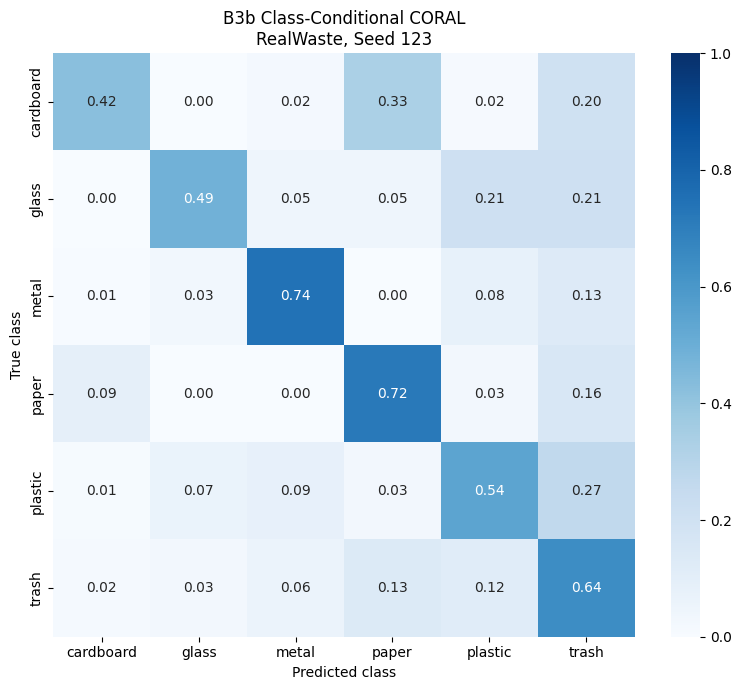


TARGET RESULTS
{
  "model": "ResNet50",
  "experiment_key": "B3b",
  "experiment": "B3b Class-Conditional CORAL",
  "target_dataset": "realwaste",
  "seed": 123,
  "source_train_images": 8442,
  "source_validation_images": 1492,
  "target_test_images": 3587,
  "accuracy": 0.604126010593811,
  "macro_precision": 0.6359051290010592,
  "macro_recall": 0.593757515166519,
  "macro_f1": 0.5946849319983717,
  "weighted_f1": 0.6120125256952196,
  "balanced_accuracy": 0.593757515166519,
  "mcc": 0.5265574588620677,
  "best_validation_epoch": 8,
  "best_validation_macro_f1": 0.9280192102724394,
  "generalization_gap": 0.3333342782740677,
  "balanced_sampling": true,
  "use_ccoral": true,
  "coral_weight": 0.1,
  "training_minutes": 22.066342131296793
}

B3b SEED 123 COMPLETED
{
  "model": "ResNet50",
  "experiment_key": "B3b",
  "experiment": "B3b Class-Conditional CORAL",
  "target_dataset": "realwaste",
  "seed": 123,
  "source_train_images": 8442,
  "source_validation_images": 1492,
  "targe

In [ ]:
# ================================================================
# RUN B3b SEED 123 ONLY
# ================================================================

import gc
import json
import torch

gc.collect()
torch.cuda.empty_cache()

try:
    torch.cuda.ipc_collect()
except Exception:
    pass

print(
    "GPU allocated before training:",
    f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB"
)

print(
    "GPU reserved before training:",
    f"{torch.cuda.memory_reserved() / 1024**3:.3f} GB"
)

result_b3b_123 = run_experiment(
    experiment_key="B3b",
    seed=123,
)

print(
    "\nB3b SEED 123 COMPLETED"
)

print(
    json.dumps(
        result_b3b_123,
        indent=2,
    )
)

# Confirm all final files.
b3b_123_directory = (
    MULTISEED_ROOT /
    "B3b_seed123"
)

required_files = [
    "target_metrics.json",
    "target_predictions.csv",
    "classification_report.csv",
    "training_history.csv",
    "normalized_confusion_matrix.png",
    "best_B3b_seed123.pt",
]

print(
    "\nSAVED FILE VERIFICATION"
)

all_files_present = True

for filename in required_files:

    exists = (
        b3b_123_directory /
        filename
    ).exists()

    print(
        filename,
        "->",
        exists,
    )

    if not exists:
        all_files_present = False

if not all_files_present:

    raise RuntimeError(
        "B3b seed 123 did not save all required outputs."
    )

# Release GPU after all files are saved.
if "result_b3b_123" in globals():
    del result_b3b_123

gc.collect()
torch.cuda.empty_cache()

try:
    torch.cuda.ipc_collect()
except Exception:
    pass

torch.cuda.synchronize()

free_bytes, total_bytes = (
    torch.cuda.mem_get_info()
)

print(
    "\nGPU allocated after cleanup:",
    f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB"
)

print(
    "GPU reserved after cleanup:",
    f"{torch.cuda.memory_reserved() / 1024**3:.3f} GB"
)

print(
    "GPU free after cleanup:",
    f"{free_bytes / 1024**3:.2f} GB"
)

GPU allocated before training: 0.017 GB
GPU reserved before training: 0.021 GB

Starting B0 Standard ResNet50 | Seed 2026
Balanced sampling: False
Class-conditional CORAL: False
CORAL weight: 0.0
B0 Seed 2026 | Epoch 01/20 | Total 0.6313 | CE 0.6313 | CCORAL 0.0000 | Train F1 0.7836 | Val F1 0.9091 | Aligned 0.00/6 | LR 1.00e-04
B0 Seed 2026 | Epoch 02/20 | Total 0.2648 | CE 0.2648 | CCORAL 0.0000 | Train F1 0.9062 | Val F1 0.9239 | Aligned 0.00/6 | LR 1.00e-04
B0 Seed 2026 | Epoch 03/20 | Total 0.1686 | CE 0.1686 | CCORAL 0.0000 | Train F1 0.9395 | Val F1 0.9145 | Aligned 0.00/6 | LR 1.00e-04
B0 Seed 2026 | Epoch 04/20 | Total 0.1293 | CE 0.1293 | CCORAL 0.0000 | Train F1 0.9538 | Val F1 0.9235 | Aligned 0.00/6 | LR 1.00e-04
B0 Seed 2026 | Epoch 05/20 | Total 0.1009 | CE 0.1009 | CCORAL 0.0000 | Train F1 0.9637 | Val F1 0.9296 | Aligned 0.00/6 | LR 1.00e-04
B0 Seed 2026 | Epoch 06/20 | Total 0.0864 | CE 0.0864 | CCORAL 0.0000 | Train F1 0.9705 | Val F1 0.9267 | Aligned 0.00/6 | LR 1.0

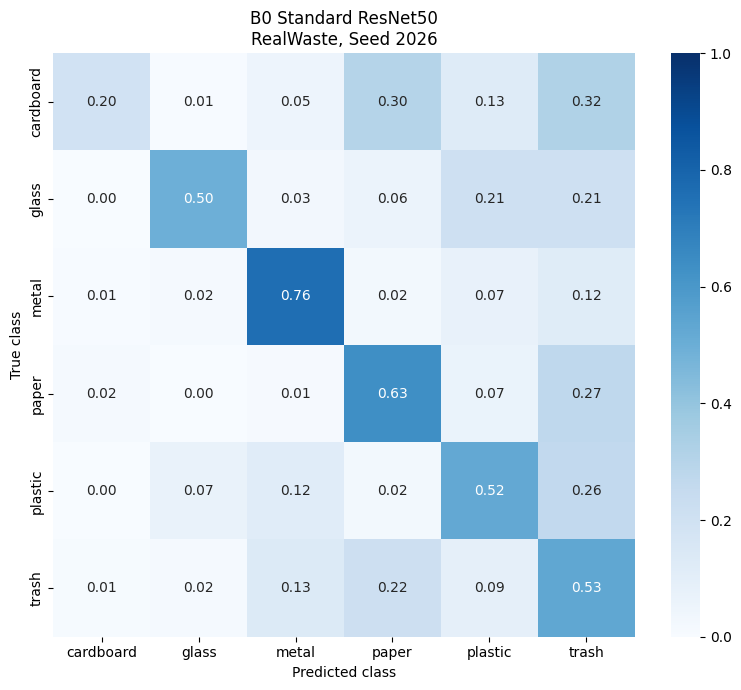


TARGET RESULTS
{
  "model": "ResNet50",
  "experiment_key": "B0",
  "experiment": "B0 Standard ResNet50",
  "target_dataset": "realwaste",
  "seed": 2026,
  "source_train_images": 8442,
  "source_validation_images": 1492,
  "target_test_images": 3587,
  "accuracy": 0.547253972679119,
  "macro_precision": 0.6131447975204884,
  "macro_recall": 0.5238314425659509,
  "macro_f1": 0.5229803721113649,
  "weighted_f1": 0.5482626059771918,
  "balanced_accuracy": 0.5238314425659509,
  "mcc": 0.45652605671120294,
  "best_validation_epoch": 7,
  "best_validation_macro_f1": 0.9386462254336467,
  "generalization_gap": 0.4156658533222818,
  "balanced_sampling": false,
  "use_ccoral": false,
  "coral_weight": 0.0,
  "training_minutes": 21.421889801820118
}

B0 SEED 2026 COMPLETED
{
  "model": "ResNet50",
  "experiment_key": "B0",
  "experiment": "B0 Standard ResNet50",
  "target_dataset": "realwaste",
  "seed": 2026,
  "source_train_images": 8442,
  "source_validation_images": 1492,
  "target_test_im

In [ ]:
# ================================================================
# RUN B0 SEED 2026 ONLY
# ================================================================

import gc
import json
import torch

gc.collect()
torch.cuda.empty_cache()

try:
    torch.cuda.ipc_collect()
except Exception:
    pass

torch.cuda.synchronize()

print(
    "GPU allocated before training:",
    f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB"
)

print(
    "GPU reserved before training:",
    f"{torch.cuda.memory_reserved() / 1024**3:.3f} GB"
)

result_b0_2026 = run_experiment(
    experiment_key="B0",
    seed=2026,
)

print(
    "\nB0 SEED 2026 COMPLETED"
)

print(
    json.dumps(
        result_b0_2026,
        indent=2,
    )
)

b0_2026_directory = (
    MULTISEED_ROOT /
    "B0_seed2026"
)

required_files = [
    "target_metrics.json",
    "target_predictions.csv",
    "classification_report.csv",
    "training_history.csv",
    "normalized_confusion_matrix.png",
    "best_B0_seed2026.pt",
]

print(
    "\nSAVED FILE VERIFICATION"
)

all_files_present = True

for filename in required_files:

    exists = (
        b0_2026_directory /
        filename
    ).exists()

    print(
        filename,
        "->",
        exists,
    )

    if not exists:
        all_files_present = False

if not all_files_present:

    raise RuntimeError(
        "B0 seed 2026 did not save all required outputs."
    )

del result_b0_2026

gc.collect()
torch.cuda.empty_cache()

try:
    torch.cuda.ipc_collect()
except Exception:
    pass

torch.cuda.synchronize()

free_bytes, total_bytes = (
    torch.cuda.mem_get_info()
)

print(
    "\nGPU allocated after cleanup:",
    f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB"
)

print(
    "GPU reserved after cleanup:",
    f"{torch.cuda.memory_reserved() / 1024**3:.3f} GB"
)

print(
    "GPU free after cleanup:",
    f"{free_bytes / 1024**3:.2f} GB"
)

GPU allocated before training: 0.017 GB
GPU reserved before training: 0.021 GB

Starting B3a Balanced Sampling | Seed 2026
Balanced sampling: True
Class-conditional CORAL: False
CORAL weight: 0.0
B3a Seed 2026 | Epoch 01/20 | Total 0.4763 | CE 0.4763 | CCORAL 0.0000 | Train F1 0.8289 | Val F1 0.8862 | Aligned 0.00/6 | LR 1.00e-04
B3a Seed 2026 | Epoch 02/20 | Total 0.1660 | CE 0.1660 | CCORAL 0.0000 | Train F1 0.9409 | Val F1 0.9133 | Aligned 0.00/6 | LR 1.00e-04
B3a Seed 2026 | Epoch 03/20 | Total 0.0996 | CE 0.0996 | CCORAL 0.0000 | Train F1 0.9638 | Val F1 0.9046 | Aligned 0.00/6 | LR 1.00e-04
B3a Seed 2026 | Epoch 04/20 | Total 0.0814 | CE 0.0814 | CCORAL 0.0000 | Train F1 0.9726 | Val F1 0.9157 | Aligned 0.00/6 | LR 1.00e-04
B3a Seed 2026 | Epoch 05/20 | Total 0.0717 | CE 0.0717 | CCORAL 0.0000 | Train F1 0.9742 | Val F1 0.9168 | Aligned 0.00/6 | LR 1.00e-04
B3a Seed 2026 | Epoch 06/20 | Total 0.0625 | CE 0.0625 | CCORAL 0.0000 | Train F1 0.9783 | Val F1 0.9207 | Aligned 0.00/6 | 

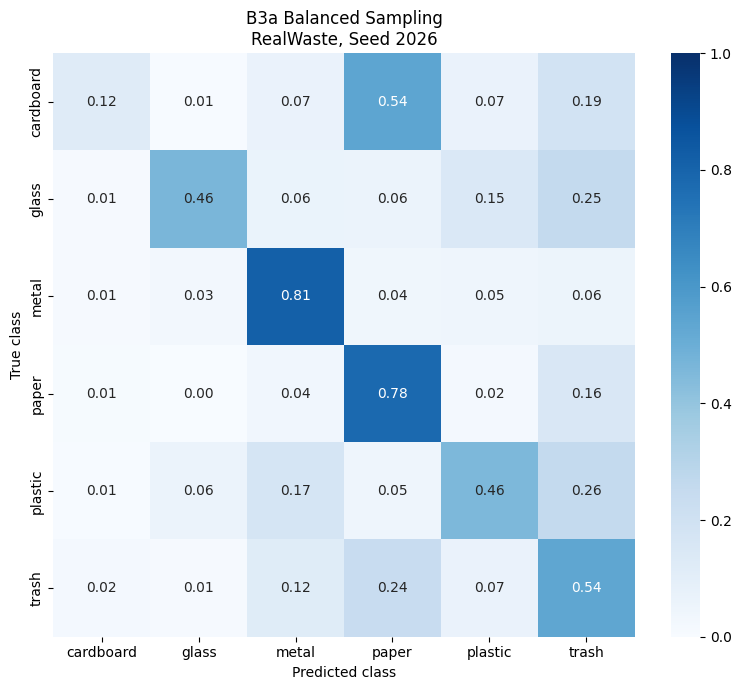


TARGET RESULTS
{
  "model": "ResNet50",
  "experiment_key": "B3a",
  "experiment": "B3a Balanced Sampling",
  "target_dataset": "realwaste",
  "seed": 2026,
  "source_train_images": 8442,
  "source_validation_images": 1492,
  "target_test_images": 3587,
  "accuracy": 0.54892667967661,
  "macro_precision": 0.5779371620472253,
  "macro_recall": 0.5285141025257033,
  "macro_f1": 0.505439369763318,
  "weighted_f1": 0.5328390662315216,
  "balanced_accuracy": 0.5285141025257033,
  "mcc": 0.46296283719579717,
  "best_validation_epoch": 19,
  "best_validation_macro_f1": 0.9320478589450755,
  "generalization_gap": 0.4266084891817574,
  "balanced_sampling": true,
  "use_ccoral": false,
  "coral_weight": 0.0,
  "training_minutes": 32.547646570205686
}

B3a SEED 2026 COMPLETED
{
  "model": "ResNet50",
  "experiment_key": "B3a",
  "experiment": "B3a Balanced Sampling",
  "target_dataset": "realwaste",
  "seed": 2026,
  "source_train_images": 8442,
  "source_validation_images": 1492,
  "target_test

In [ ]:
# ================================================================
# RUN B3a SEED 2026 ONLY
# ================================================================

import gc
import json
import torch

gc.collect()
torch.cuda.empty_cache()

try:
    torch.cuda.ipc_collect()
except Exception:
    pass

torch.cuda.synchronize()

print(
    "GPU allocated before training:",
    f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB"
)

print(
    "GPU reserved before training:",
    f"{torch.cuda.memory_reserved() / 1024**3:.3f} GB"
)

result_b3a_2026 = run_experiment(
    experiment_key="B3a",
    seed=2026,
)

print(
    "\nB3a SEED 2026 COMPLETED"
)

print(
    json.dumps(
        result_b3a_2026,
        indent=2,
    )
)

b3a_2026_directory = (
    MULTISEED_ROOT /
    "B3a_seed2026"
)

required_files = [
    "target_metrics.json",
    "target_predictions.csv",
    "classification_report.csv",
    "training_history.csv",
    "normalized_confusion_matrix.png",
    "best_B3a_seed2026.pt",
]

print(
    "\nSAVED FILE VERIFICATION"
)

all_files_present = True

for filename in required_files:

    exists = (
        b3a_2026_directory /
        filename
    ).exists()

    print(
        filename,
        "->",
        exists,
    )

    if not exists:
        all_files_present = False

if not all_files_present:

    raise RuntimeError(
        "B3a seed 2026 did not save all required outputs."
    )

del result_b3a_2026

gc.collect()
torch.cuda.empty_cache()

try:
    torch.cuda.ipc_collect()
except Exception:
    pass

torch.cuda.synchronize()

free_bytes, total_bytes = (
    torch.cuda.mem_get_info()
)

print(
    "\nGPU allocated after cleanup:",
    f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB"
)

print(
    "GPU reserved after cleanup:",
    f"{torch.cuda.memory_reserved() / 1024**3:.3f} GB"
)

print(
    "GPU free after cleanup:",
    f"{free_bytes / 1024**3:.2f} GB"
)

GPU allocated before training: 0.017 GB
GPU reserved before training: 0.021 GB

Starting B3b Class-Conditional CORAL | Seed 2026
Balanced sampling: True
Class-conditional CORAL: True
CORAL weight: 0.1
B3b Seed 2026 | Epoch 01/20 | Total 0.5759 | CE 0.4801 | CCORAL 0.9580 | Train F1 0.8246 | Val F1 0.8740 | Aligned 6.00/6 | LR 1.00e-04
B3b Seed 2026 | Epoch 02/20 | Total 0.2044 | CE 0.1682 | CCORAL 0.3618 | Train F1 0.9421 | Val F1 0.9087 | Aligned 6.00/6 | LR 1.00e-04
B3b Seed 2026 | Epoch 03/20 | Total 0.1221 | CE 0.0981 | CCORAL 0.2396 | Train F1 0.9650 | Val F1 0.8970 | Aligned 6.00/6 | LR 1.00e-04
B3b Seed 2026 | Epoch 04/20 | Total 0.1093 | CE 0.0906 | CCORAL 0.1862 | Train F1 0.9692 | Val F1 0.9083 | Aligned 6.00/6 | LR 1.00e-04
B3b Seed 2026 | Epoch 05/20 | Total 0.1019 | CE 0.0863 | CCORAL 0.1565 | Train F1 0.9707 | Val F1 0.9213 | Aligned 6.00/6 | LR 1.00e-04
B3b Seed 2026 | Epoch 06/20 | Total 0.0729 | CE 0.0602 | CCORAL 0.1264 | Train F1 0.9791 | Val F1 0.9290 | Aligned 6.00

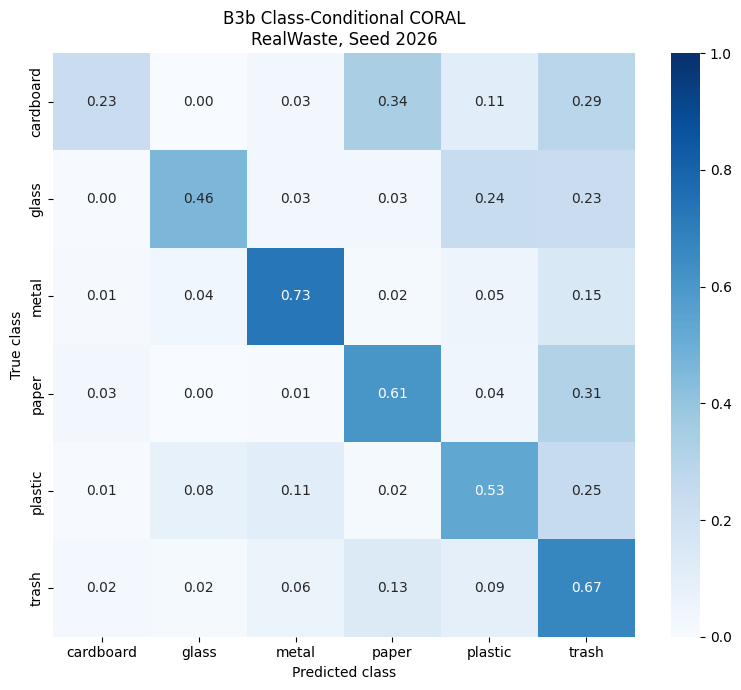


TARGET RESULTS
{
  "model": "ResNet50",
  "experiment_key": "B3b",
  "experiment": "B3b Class-Conditional CORAL",
  "target_dataset": "realwaste",
  "seed": 2026,
  "source_train_images": 8442,
  "source_validation_images": 1492,
  "target_test_images": 3587,
  "accuracy": 0.5581265681628101,
  "macro_precision": 0.6036082881012086,
  "macro_recall": 0.5387304503509937,
  "macro_f1": 0.536044641214475,
  "weighted_f1": 0.561495211023041,
  "balanced_accuracy": 0.5387304503509937,
  "mcc": 0.47315110050556414,
  "best_validation_epoch": 20,
  "best_validation_macro_f1": 0.9483851997732834,
  "generalization_gap": 0.41234055855880836,
  "balanced_sampling": true,
  "use_ccoral": true,
  "coral_weight": 0.1,
  "training_minutes": 34.55113021532694
}

B3b SEED 2026 COMPLETED
{
  "model": "ResNet50",
  "experiment_key": "B3b",
  "experiment": "B3b Class-Conditional CORAL",
  "target_dataset": "realwaste",
  "seed": 2026,
  "source_train_images": 8442,
  "source_validation_images": 1492,
  

In [ ]:
# ================================================================
# RUN B3b SEED 2026 — FINAL TRAINING EXPERIMENT
# ================================================================

import gc
import json
import torch

gc.collect()
torch.cuda.empty_cache()

try:
    torch.cuda.ipc_collect()
except Exception:
    pass

torch.cuda.synchronize()

print(
    "GPU allocated before training:",
    f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB"
)

print(
    "GPU reserved before training:",
    f"{torch.cuda.memory_reserved() / 1024**3:.3f} GB"
)

result_b3b_2026 = run_experiment(
    experiment_key="B3b",
    seed=2026,
)

print(
    "\nB3b SEED 2026 COMPLETED"
)

print(
    json.dumps(
        result_b3b_2026,
        indent=2,
    )
)

b3b_2026_directory = (
    MULTISEED_ROOT /
    "B3b_seed2026"
)

required_files = [
    "target_metrics.json",
    "target_predictions.csv",
    "classification_report.csv",
    "training_history.csv",
    "normalized_confusion_matrix.png",
    "best_B3b_seed2026.pt",
]

print(
    "\nSAVED FILE VERIFICATION"
)

all_files_present = True

for filename in required_files:

    exists = (
        b3b_2026_directory /
        filename
    ).exists()

    print(
        filename,
        "->",
        exists,
    )

    if not exists:
        all_files_present = False

if not all_files_present:

    raise RuntimeError(
        "B3b seed 2026 did not save all required outputs."
    )

# Preserve printed results in Drive before releasing memory.
with open(
    MULTISEED_ROOT /
    "final_completed_training_marker.json",
    "w",
) as file:

    json.dump(
        {
            "status": (
                "all_multiseed_training_completed"
            ),
            "last_experiment": "B3b",
            "last_seed": 2026,
            "target": "realwaste",
            "required_seeds": [
                42,
                123,
                2026,
            ],
        },
        file,
        indent=2,
    )

del result_b3b_2026

gc.collect()
torch.cuda.empty_cache()

try:
    torch.cuda.ipc_collect()
except Exception:
    pass

torch.cuda.synchronize()

free_bytes, total_bytes = (
    torch.cuda.mem_get_info()
)

print(
    "\nGPU allocated after cleanup:",
    f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB"
)

print(
    "GPU reserved after cleanup:",
    f"{torch.cuda.memory_reserved() / 1024**3:.3f} GB"
)

print(
    "GPU free after cleanup:",
    f"{free_bytes / 1024**3:.2f} GB"
)

print(
    "\nALL REQUIRED TRAINING RUNS ARE NOW COMPLETE."
)

Paper results directory: /content/drive/MyDrive/Waste_Publication/results/paper_ready_analysis

RESULT FILE AUDIT


,experiment_key,experiment,seed,directory,metrics_exists,predictions_exists,report_exists,history_exists,complete
0,B0,B0 Standard ResNet50,42,/content/drive/MyDrive/Waste_Publication/resul...,True,True,True,True,True
1,B3a,B3a Balanced Sampling,42,/content/drive/MyDrive/Waste_Publication/resul...,True,True,True,True,True
2,B3b,B3b Class-Conditional CORAL,42,/content/drive/MyDrive/Waste_Publication/resul...,True,True,True,True,True
3,B0,B0 Standard ResNet50,123,/content/drive/MyDrive/Waste_Publication/resul...,True,True,True,True,True
4,B3a,B3a Balanced Sampling,123,/content/drive/MyDrive/Waste_Publication/resul...,True,True,True,True,True
5,B3b,B3b Class-Conditional CORAL,123,/content/drive/MyDrive/Waste_Publication/resul...,True,True,True,True,True
6,B0,B0 Standard ResNet50,2026,/content/drive/MyDrive/Waste_Publication/resul...,True,True,True,True,True
7,B3a,B3a Balanced Sampling,2026,/content/drive/MyDrive/Waste_Publication/resul...,True,True,True,True,True
8,B3b,B3b Class-Conditional CORAL,2026,/content/drive/MyDrive/Waste_Publication/resul...,True,True,True,True,True



ALL SEED METRICS


,experiment_key,experiment,seed,n_target,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,balanced_accuracy,mcc,validation_macro_f1,generalization_gap,best_validation_epoch,training_minutes
0,B0,B0 Standard ResNet50,42,3587,0.584054,0.646502,0.571604,0.566549,0.585105,0.571604,0.505873,0.948664,0.382115,12,27.478640
1,B0,B0 Standard ResNet50,123,3587,0.573460,0.598834,0.552331,0.542828,0.566867,0.552331,0.486987,0.945830,0.403002,19,34.930666
2,B0,B0 Standard ResNet50,2026,3587,0.547254,0.613145,0.523831,0.522980,0.548263,0.523831,0.456526,0.938646,0.415666,7,21.421890
3,B3a,B3a Balanced Sampling,42,3587,0.543909,0.620452,0.536844,0.534158,0.554859,0.536844,0.466031,0.942603,0.408445,15,33.175429
4,B3a,B3a Balanced Sampling,123,3587,0.573181,0.587914,0.553999,0.546893,0.570547,0.553999,0.486266,0.946034,0.399141,20,33.635923
5,B3a,B3a Balanced Sampling,2026,3587,0.548927,0.577937,0.528514,0.505439,0.532839,0.528514,0.462963,0.932048,0.426608,19,32.547647
6,B3b,B3b Class-Conditional CORAL,42,3587,0.594647,0.607223,0.570853,0.566382,0.594998,0.570853,0.511612,0.939681,0.373299,19,34.624034
7,B3b,B3b Class-Conditional CORAL,123,3587,0.604126,0.635905,0.593758,0.594685,0.612013,0.593758,0.526557,0.928019,0.333334,8,22.066342
8,B3b,B3b Class-Conditional CORAL,2026,3587,0.558127,0.603608,0.538730,0.536045,0.561495,0.538730,0.473151,0.948385,0.412341,20,34.551130



PAPER-READY MEAN ± SD


...

,seed,comparison,both_correct,B0_only_correct,comparator_only_correct,both_wrong,discordant_pairs,p_value,significant_at_0.05
0,42,B3a vs B0,1684,411,267,1225,678,3.550023e-08,True
1,42,B3b vs B0,1749,346,384,1108,730,1.708217e-01,False
2,123,B3a vs B0,1742,315,314,1216,629,1.000000e+00,False
3,123,B3b vs B0,1750,307,417,1113,724,4.945286e-05,True
4,2026,B3a vs B0,1623,340,346,1278,686,8.486208e-01,False
5,2026,B3b vs B0,1619,344,383,1241,727,1.586870e-01,False



BOOTSTRAP MACRO-F1 DIFFERENCES


,seed,comparison,observed_macro_f1_difference,ci_95_lower,ci_95_upper,bootstrap_probability_above_zero,significant_positive,significant_negative,bootstrap_repetitions
0,42,B3a-B0,-0.032391,-0.047466,-0.016486,0.0000,False,True,5000
1,42,B3b-B0,-0.000168,-0.015650,0.015382,0.4956,False,False,5000
2,123,B3a-B0,0.004065,-0.011256,0.018859,0.7074,False,False,5000
3,123,B3b-B0,0.051857,0.036007,0.067835,1.0000,True,False,5000
4,2026,B3a-B0,-0.017541,-0.032735,-0.002256,0.0128,False,True,5000
5,2026,B3b-B0,0.013064,-0.002603,0.029437,0.9466,False,False,5000



HIERARCHICAL MULTI-SEED BOOTSTRAP


,comparison,observed_mean_macro_f1_difference,ci_95_lower,ci_95_upper,probability_above_zero,significant_positive,repetitions
0,B3a-B0,-0.015289,-0.032973,0.004082,0.0628,False,5000
1,B3b-B0,0.021584,-0.001665,0.051075,0.9570,False,5000


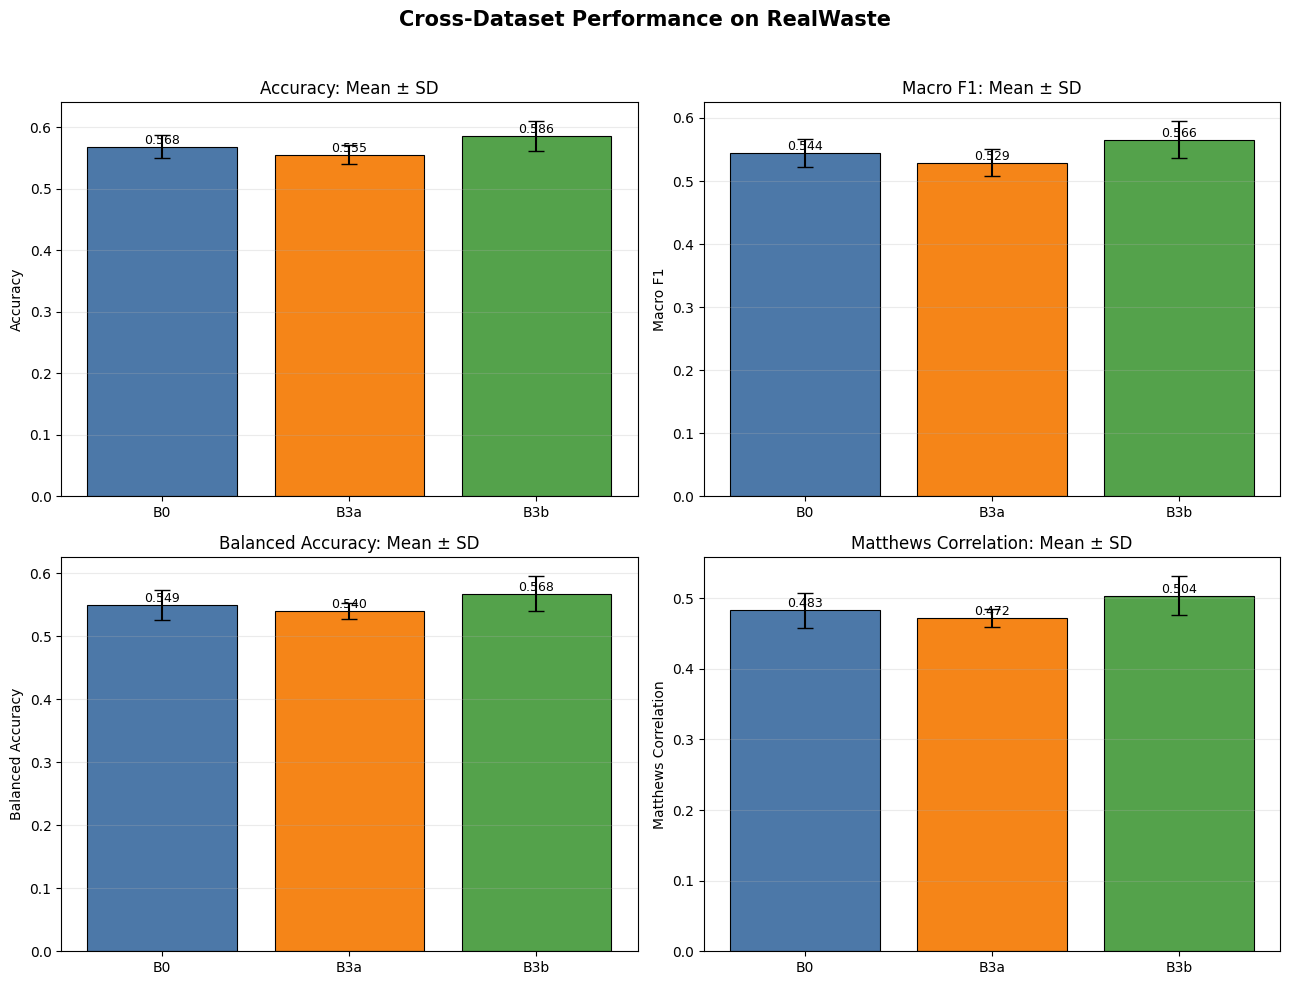

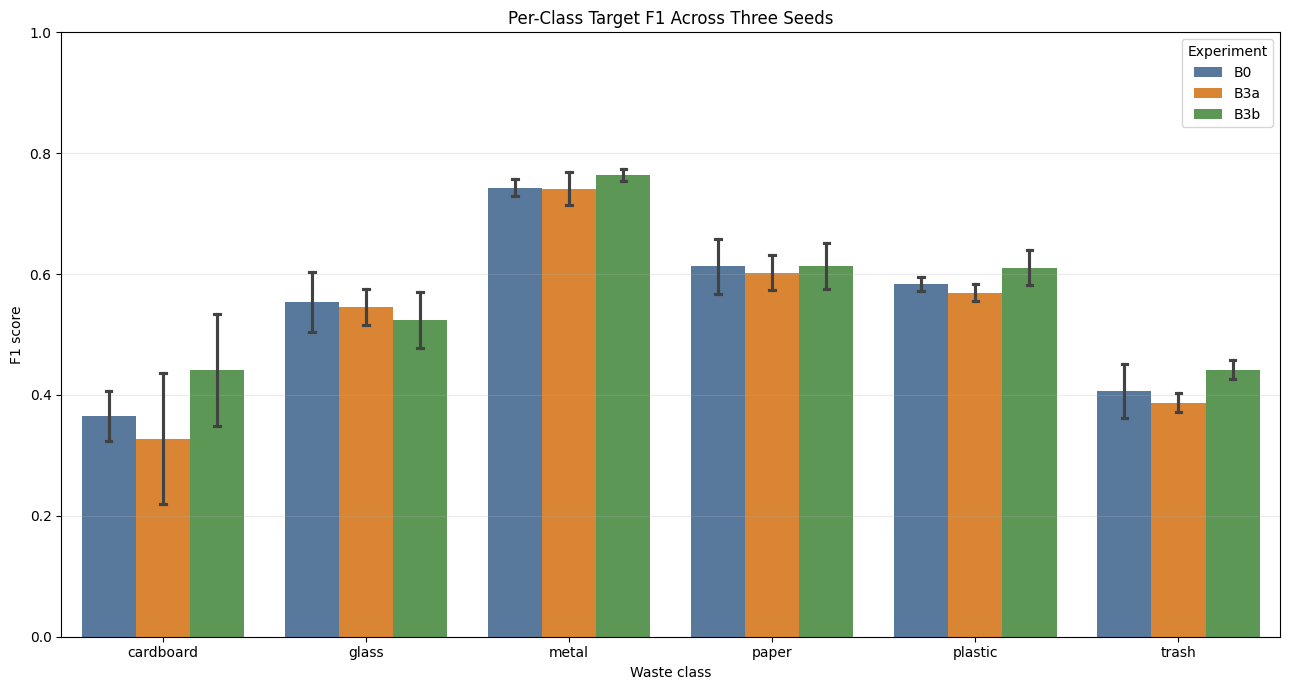

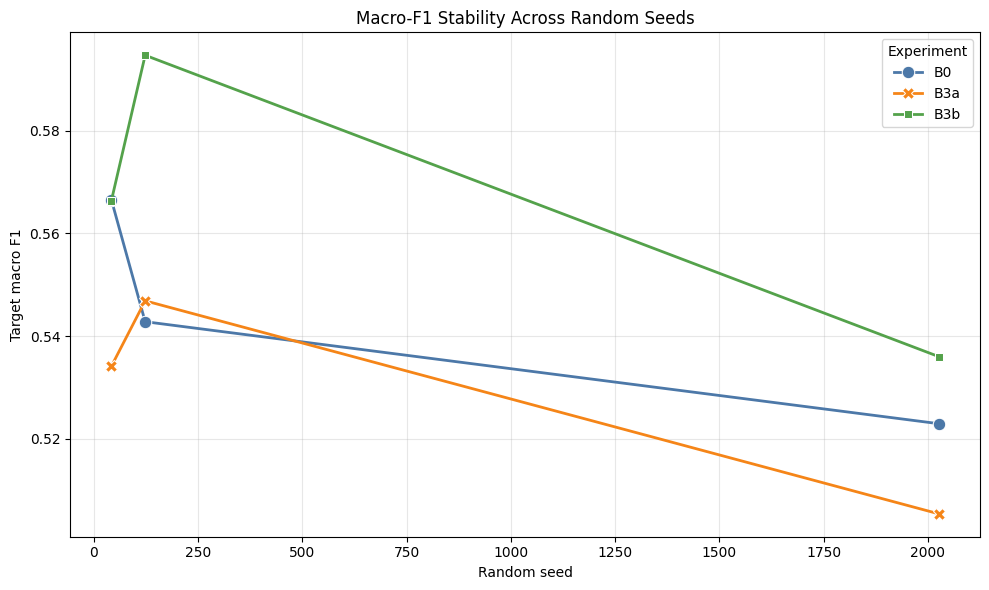


FINAL MODEL RANKING


,experiment_key,experiment,macro_f1_mean,macro_f1_sd,accuracy_mean,mcc_mean,gap_mean,rank
0,B3b,B3b Class-Conditional CORAL,0.565704,0.029326,0.585633,0.503773,0.372991,1
1,B0,B0 Standard ResNet50,0.544119,0.021813,0.568256,0.483128,0.400261,2
2,B3a,B3a Balanced Sampling,0.528830,0.021234,0.555339,0.471753,0.411398,3



Selected model: B3b Class-Conditional CORAL

All paper-ready analysis saved to: /content/drive/MyDrive/Waste_Publication/results/paper_ready_analysis


In [ ]:
# ================================================================
# PAPER-READY MULTI-SEED ANALYSIS
# CPU ONLY — NO GPU REQUIRED
# ================================================================

import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    balanced_accuracy_score,
    matthews_corrcoef,
    f1_score,
)

from statsmodels.stats.contingency_tables import (
    mcnemar
)

# ================================================================
# 1. Paths
# ================================================================

DRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)

PUBLICATION_ROOT = (
    DRIVE_ROOT /
    "Waste_Publication"
)

RESULTS_ROOT = (
    PUBLICATION_ROOT /
    "results"
)

MULTISEED_ROOT = (
    RESULTS_ROOT /
    "multiseed_confirmation"
)

PAPER_RESULTS_DIR = (
    RESULTS_ROOT /
    "paper_ready_analysis"
)

PAPER_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SEEDS = [
    42,
    123,
    2026,
]

EXPERIMENT_NAMES = {
    "B0": "B0 Standard ResNet50",
    "B3a": "B3a Balanced Sampling",
    "B3b": (
        "B3b Class-Conditional CORAL"
    ),
}

RUN_DIRECTORIES = {
    ("B0", 42): (
        RESULTS_ROOT /
        "resnet50_target_realwaste"
    ),
    ("B3a", 42): (
        RESULTS_ROOT /
        "B3a_balanced_sampling_target_realwaste_seed42"
    ),
    ("B3b", 42): (
        RESULTS_ROOT /
        "B3b_class_conditional_coral_target_realwaste_seed42"
    ),
    ("B0", 123): (
        MULTISEED_ROOT /
        "B0_seed123"
    ),
    ("B3a", 123): (
        MULTISEED_ROOT /
        "B3a_seed123"
    ),
    ("B3b", 123): (
        MULTISEED_ROOT /
        "B3b_seed123"
    ),
    ("B0", 2026): (
        MULTISEED_ROOT /
        "B0_seed2026"
    ),
    ("B3a", 2026): (
        MULTISEED_ROOT /
        "B3a_seed2026"
    ),
    ("B3b", 2026): (
        MULTISEED_ROOT /
        "B3b_seed2026"
    ),
}

print(
    "Paper results directory:",
    PAPER_RESULTS_DIR,
)

# ================================================================
# 2. Verify all required result files
# ================================================================

audit_rows = []

for (
    experiment_key,
    seed,
), run_directory in RUN_DIRECTORIES.items():

    required_files = {
        "metrics": (
            run_directory /
            "target_metrics.json"
        ),
        "predictions": (
            run_directory /
            "target_predictions.csv"
        ),
        "report": (
            run_directory /
            "classification_report.csv"
        ),
        "history": (
            run_directory /
            "training_history.csv"
        ),
    }

    audit_row = {
        "experiment_key": experiment_key,
        "experiment": (
            EXPERIMENT_NAMES[
                experiment_key
            ]
        ),
        "seed": seed,
        "directory": str(
            run_directory
        ),
    }

    for file_type, file_path in (
        required_files.items()
    ):

        audit_row[
            f"{file_type}_exists"
        ] = file_path.exists()

    audit_row["complete"] = all(
        file_path.exists()
        for file_path in (
            required_files.values()
        )
    )

    audit_rows.append(
        audit_row
    )

audit_df = pd.DataFrame(
    audit_rows
)

audit_df.to_csv(
    PAPER_RESULTS_DIR /
    "result_file_audit.csv",
    index=False,
)

print("\nRESULT FILE AUDIT")
display(audit_df)

if not audit_df["complete"].all():

    incomplete = audit_df[
        ~audit_df["complete"]
    ]

    raise FileNotFoundError(
        "Some runs are incomplete:\n"
        f"{incomplete}"
    )

# ================================================================
# 3. Prediction-column normalization
# ================================================================

def normalize_prediction_columns(
    prediction_df,
):

    dataframe = prediction_df.copy()

    if (
        "true_label"
        not in dataframe.columns
    ):

        if (
            "label"
            in dataframe.columns
        ):

            dataframe[
                "true_label"
            ] = dataframe["label"]

        else:

            raise ValueError(
                "Prediction file has no "
                "true-label column."
            )

    if (
        "predicted_label"
        not in dataframe.columns
    ):

        raise ValueError(
            "Prediction file has no "
            "predicted_label column."
        )

    if "sha256" in dataframe.columns:

        dataframe[
            "sample_id"
        ] = dataframe[
            "sha256"
        ].astype(str)

    elif "path" in dataframe.columns:

        dataframe[
            "sample_id"
        ] = dataframe[
            "path"
        ].astype(str)

    else:

        dataframe[
            "sample_id"
        ] = np.arange(
            len(dataframe)
        ).astype(str)

    dataframe[
        "true_label"
    ] = dataframe[
        "true_label"
    ].astype(str)

    dataframe[
        "predicted_label"
    ] = dataframe[
        "predicted_label"
    ].astype(str)

    dataframe["correct"] = (
        dataframe["true_label"]
        ==
        dataframe["predicted_label"]
    )

    return dataframe

# ================================================================
# 4. Recalculate every metric consistently
# ================================================================

all_metric_rows = []
prediction_tables = {}

for (
    experiment_key,
    seed,
), run_directory in RUN_DIRECTORIES.items():

    prediction_path = (
        run_directory /
        "target_predictions.csv"
    )

    prediction_df = pd.read_csv(
        prediction_path
    )

    prediction_df = (
        normalize_prediction_columns(
            prediction_df
        )
    )

    prediction_tables[
        (
            experiment_key,
            seed,
        )
    ] = prediction_df

    y_true = prediction_df[
        "true_label"
    ].to_numpy()

    y_pred = prediction_df[
        "predicted_label"
    ].to_numpy()

    (
        macro_precision,
        macro_recall,
        macro_f1,
        _,
    ) = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        )[2]
    )

    with open(
        run_directory /
        "target_metrics.json",
        "r",
    ) as file:

        saved_metrics = json.load(file)

    validation_f1 = float(
        saved_metrics[
            "best_validation_macro_f1"
        ]
    )

    recalculated_row = {
        "experiment_key": (
            experiment_key
        ),
        "experiment": (
            EXPERIMENT_NAMES[
                experiment_key
            ]
        ),
        "seed": seed,
        "n_target": len(
            prediction_df
        ),
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "macro_precision": (
            macro_precision
        ),
        "macro_recall": (
            macro_recall
        ),
        "macro_f1": macro_f1,
        "weighted_f1": (
            weighted_f1
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "mcc": matthews_corrcoef(
            y_true,
            y_pred,
        ),
        "validation_macro_f1": (
            validation_f1
        ),
        "generalization_gap": (
            validation_f1 -
            macro_f1
        ),
        "best_validation_epoch": (
            saved_metrics[
                "best_validation_epoch"
            ]
        ),
        "training_minutes": (
            saved_metrics.get(
                "training_minutes",
                np.nan,
            )
        ),
    }

    all_metric_rows.append(
        recalculated_row
    )

all_seed_metrics_df = pd.DataFrame(
    all_metric_rows
)

experiment_order = {
    "B0": 0,
    "B3a": 1,
    "B3b": 2,
}

all_seed_metrics_df[
    "_order"
] = all_seed_metrics_df[
    "experiment_key"
].map(experiment_order)

all_seed_metrics_df = (
    all_seed_metrics_df
    .sort_values(
        [
            "_order",
            "seed",
        ]
    )
    .drop(
        columns="_order"
    )
    .reset_index(drop=True)
)

all_seed_metrics_df.to_csv(
    PAPER_RESULTS_DIR /
    "table_all_seed_metrics.csv",
    index=False,
)

print("\nALL SEED METRICS")
display(all_seed_metrics_df)

# ================================================================
# 5. Mean ± standard deviation
# ================================================================

SUMMARY_METRICS = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "balanced_accuracy",
    "mcc",
    "generalization_gap",
]

numeric_summary = (
    all_seed_metrics_df
    .groupby(
        [
            "experiment_key",
            "experiment",
        ],
        observed=True,
    )[SUMMARY_METRICS]
    .agg(["mean", "std"])
    .reset_index()
)

numeric_summary.to_csv(
    PAPER_RESULTS_DIR /
    "table_numeric_mean_sd.csv",
    index=False,
)

paper_rows = []

for experiment_key in [
    "B0",
    "B3a",
    "B3b",
]:

    experiment_data = (
        all_seed_metrics_df[
            all_seed_metrics_df[
                "experiment_key"
            ]
            ==
            experiment_key
        ]
    )

    row = {
        "Experiment": (
            EXPERIMENT_NAMES[
                experiment_key
            ]
        ),
        "Seeds": len(
            experiment_data
        ),
    }

    for metric in SUMMARY_METRICS:

        values = (
            experiment_data[metric]
            .astype(float)
        )

        if metric == "mcc":

            row[metric] = (
                f"{values.mean():.4f} "
                f"± {values.std(ddof=1):.4f}"
            )

        else:

            row[metric] = (
                f"{values.mean() * 100:.2f} "
                f"± "
                f"{values.std(ddof=1) * 100:.2f}"
            )

    paper_rows.append(row)

paper_summary_df = pd.DataFrame(
    paper_rows
)

paper_summary_df.to_csv(
    PAPER_RESULTS_DIR /
    "table_paper_mean_sd.csv",
    index=False,
)

print("\nPAPER-READY MEAN ± SD")
display(paper_summary_df)

# ================================================================
# 6. Per-class F1 for every seed
# ================================================================

class_rows = []

for (
    experiment_key,
    seed,
), prediction_df in (
    prediction_tables.items()
):

    y_true = prediction_df[
        "true_label"
    ].to_numpy()

    y_pred = prediction_df[
        "predicted_label"
    ].to_numpy()

    class_names = sorted(
        np.unique(y_true)
    )

    (
        class_precision,
        class_recall,
        class_f1,
        class_support,
    ) = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=class_names,
        average=None,
        zero_division=0,
    )

    for (
        class_name,
        precision,
        recall,
        f1_value,
        support,
    ) in zip(
        class_names,
        class_precision,
        class_recall,
        class_f1,
        class_support,
    ):

        class_rows.append({
            "experiment_key": (
                experiment_key
            ),
            "experiment": (
                EXPERIMENT_NAMES[
                    experiment_key
                ]
            ),
            "seed": seed,
            "class": class_name,
            "precision": precision,
            "recall": recall,
            "f1": f1_value,
            "support": support,
        })

per_class_seed_df = pd.DataFrame(
    class_rows
)

per_class_seed_df.to_csv(
    PAPER_RESULTS_DIR /
    "table_per_class_all_seeds.csv",
    index=False,
)

per_class_summary_df = (
    per_class_seed_df
    .groupby(
        [
            "experiment_key",
            "experiment",
            "class",
        ],
        observed=True,
    )
    .agg(
        precision_mean=(
            "precision",
            "mean",
        ),
        precision_sd=(
            "precision",
            "std",
        ),
        recall_mean=(
            "recall",
            "mean",
        ),
        recall_sd=(
            "recall",
            "std",
        ),
        f1_mean=(
            "f1",
            "mean",
        ),
        f1_sd=(
            "f1",
            "std",
        ),
        support=(
            "support",
            "first",
        ),
    )
    .reset_index()
)

per_class_summary_df.to_csv(
    PAPER_RESULTS_DIR /
    "table_per_class_mean_sd.csv",
    index=False,
)

print("\nPER-CLASS MEAN ± SD")
display(per_class_summary_df)

# ================================================================
# 7. Seed-level paired changes
# ================================================================

comparison_rows = []

for seed in SEEDS:

    seed_results = (
        all_seed_metrics_df[
            all_seed_metrics_df[
                "seed"
            ]
            ==
            seed
        ]
        .set_index(
            "experiment_key"
        )
    )

    for comparator in [
        "B3a",
        "B3b",
    ]:

        comparison_rows.append({
            "seed": seed,
            "comparison": (
                f"{comparator}-B0"
            ),
            "accuracy_difference": (
                seed_results.loc[
                    comparator,
                    "accuracy",
                ]
                -
                seed_results.loc[
                    "B0",
                    "accuracy",
                ]
            ),
            "macro_f1_difference": (
                seed_results.loc[
                    comparator,
                    "macro_f1",
                ]
                -
                seed_results.loc[
                    "B0",
                    "macro_f1",
                ]
            ),
            "mcc_difference": (
                seed_results.loc[
                    comparator,
                    "mcc",
                ]
                -
                seed_results.loc[
                    "B0",
                    "mcc",
                ]
            ),
            "gap_difference": (
                seed_results.loc[
                    comparator,
                    "generalization_gap",
                ]
                -
                seed_results.loc[
                    "B0",
                    "generalization_gap",
                ]
            ),
        })

seed_difference_df = pd.DataFrame(
    comparison_rows
)

seed_difference_df.to_csv(
    PAPER_RESULTS_DIR /
    "table_seed_level_differences.csv",
    index=False,
)

print("\nSEED-LEVEL DIFFERENCES")
display(seed_difference_df)

# ================================================================
# 8. Align paired predictions
# ================================================================

def paired_predictions(
    experiment_a,
    experiment_b,
    seed,
):

    dataframe_a = (
        prediction_tables[
            (
                experiment_a,
                seed,
            )
        ][
            [
                "sample_id",
                "true_label",
                "predicted_label",
                "correct",
            ]
        ]
        .copy()
        .rename(
            columns={
                "true_label": (
                    "true_label_a"
                ),
                "predicted_label": (
                    "prediction_a"
                ),
                "correct": (
                    "correct_a"
                ),
            }
        )
    )

    dataframe_b = (
        prediction_tables[
            (
                experiment_b,
                seed,
            )
        ][
            [
                "sample_id",
                "true_label",
                "predicted_label",
                "correct",
            ]
        ]
        .copy()
        .rename(
            columns={
                "true_label": (
                    "true_label_b"
                ),
                "predicted_label": (
                    "prediction_b"
                ),
                "correct": (
                    "correct_b"
                ),
            }
        )
    )

    paired = dataframe_a.merge(
        dataframe_b,
        on="sample_id",
        how="inner",
        validate="one_to_one",
    )

    if len(paired) != 3587:

        raise ValueError(
            f"Expected 3587 paired images, "
            f"found {len(paired)}"
        )

    if not (
        paired["true_label_a"]
        ==
        paired["true_label_b"]
    ).all():

        raise ValueError(
            "True labels differ between runs."
        )

    return paired

# ================================================================
# 9. McNemar tests
# ================================================================

mcnemar_rows = []

for seed in SEEDS:

    for comparator in [
        "B3a",
        "B3b",
    ]:

        paired = paired_predictions(
            "B0",
            comparator,
            seed,
        )

        both_correct = int(
            (
                paired["correct_a"]
                &
                paired["correct_b"]
            ).sum()
        )

        b0_only_correct = int(
            (
                paired["correct_a"]
                &
                ~paired["correct_b"]
            ).sum()
        )

        comparator_only_correct = int(
            (
                ~paired["correct_a"]
                &
                paired["correct_b"]
            ).sum()
        )

        both_wrong = int(
            (
                ~paired["correct_a"]
                &
                ~paired["correct_b"]
            ).sum()
        )

        contingency_table = [
            [
                both_correct,
                b0_only_correct,
            ],
            [
                comparator_only_correct,
                both_wrong,
            ],
        ]

        test_result = mcnemar(
            contingency_table,
            exact=True,
        )

        mcnemar_rows.append({
            "seed": seed,
            "comparison": (
                f"{comparator} vs B0"
            ),
            "both_correct": (
                both_correct
            ),
            "B0_only_correct": (
                b0_only_correct
            ),
            "comparator_only_correct": (
                comparator_only_correct
            ),
            "both_wrong": (
                both_wrong
            ),
            "discordant_pairs": (
                b0_only_correct
                +
                comparator_only_correct
            ),
            "p_value": float(
                test_result.pvalue
            ),
            "significant_at_0.05": (
                test_result.pvalue
                <
                0.05
            ),
        })

mcnemar_df = pd.DataFrame(
    mcnemar_rows
)

mcnemar_df.to_csv(
    PAPER_RESULTS_DIR /
    "table_mcnemar_tests.csv",
    index=False,
)

print("\nMCNEMAR TESTS")
display(mcnemar_df)

# ================================================================
# 10. Paired bootstrap macro-F1 differences
# ================================================================

N_BOOTSTRAP = 5000
BOOTSTRAP_SEED = 42

bootstrap_rows = []

for seed in SEEDS:

    for comparator in [
        "B3a",
        "B3b",
    ]:

        paired = paired_predictions(
            "B0",
            comparator,
            seed,
        )

        y_true = paired[
            "true_label_a"
        ].to_numpy()

        predictions_b0 = paired[
            "prediction_a"
        ].to_numpy()

        predictions_comparator = paired[
            "prediction_b"
        ].to_numpy()

        observed_difference = (
            f1_score(
                y_true,
                predictions_comparator,
                average="macro",
                zero_division=0,
            )
            -
            f1_score(
                y_true,
                predictions_b0,
                average="macro",
                zero_division=0,
            )
        )

        rng = np.random.default_rng(
            BOOTSTRAP_SEED + seed
        )

        bootstrap_differences = np.empty(
            N_BOOTSTRAP,
            dtype=np.float64,
        )

        sample_size = len(y_true)

        for iteration in range(
            N_BOOTSTRAP
        ):

            sampled_indices = rng.integers(
                0,
                sample_size,
                size=sample_size,
            )

            b0_f1 = f1_score(
                y_true[
                    sampled_indices
                ],
                predictions_b0[
                    sampled_indices
                ],
                average="macro",
                zero_division=0,
            )

            comparator_f1 = f1_score(
                y_true[
                    sampled_indices
                ],
                predictions_comparator[
                    sampled_indices
                ],
                average="macro",
                zero_division=0,
            )

            bootstrap_differences[
                iteration
            ] = (
                comparator_f1 -
                b0_f1
            )

        confidence_lower = np.percentile(
            bootstrap_differences,
            2.5,
        )

        confidence_upper = np.percentile(
            bootstrap_differences,
            97.5,
        )

        bootstrap_rows.append({
            "seed": seed,
            "comparison": (
                f"{comparator}-B0"
            ),
            "observed_macro_f1_difference": (
                observed_difference
            ),
            "ci_95_lower": (
                confidence_lower
            ),
            "ci_95_upper": (
                confidence_upper
            ),
            "bootstrap_probability_above_zero": (
                (
                    bootstrap_differences
                    >
                    0
                ).mean()
            ),
            "significant_positive": (
                confidence_lower > 0
            ),
            "significant_negative": (
                confidence_upper < 0
            ),
            "bootstrap_repetitions": (
                N_BOOTSTRAP
            ),
        })

bootstrap_df = pd.DataFrame(
    bootstrap_rows
)

bootstrap_df.to_csv(
    PAPER_RESULTS_DIR /
    "table_bootstrap_macro_f1.csv",
    index=False,
)

print("\nBOOTSTRAP MACRO-F1 DIFFERENCES")
display(bootstrap_df)

# ================================================================
# 11. Multi-seed hierarchical bootstrap
# ================================================================

HIERARCHICAL_REPETITIONS = 5000
hierarchical_rng = (
    np.random.default_rng(2026)
)

hierarchical_rows = []

for comparator in [
    "B3a",
    "B3b",
]:

    paired_by_seed = {
        seed: paired_predictions(
            "B0",
            comparator,
            seed,
        )
        for seed in SEEDS
    }

    observed_seed_differences = []

    for seed in SEEDS:

        paired = paired_by_seed[seed]

        observed_seed_differences.append(
            f1_score(
                paired["true_label_a"],
                paired["prediction_b"],
                average="macro",
                zero_division=0,
            )
            -
            f1_score(
                paired["true_label_a"],
                paired["prediction_a"],
                average="macro",
                zero_division=0,
            )
        )

    observed_mean_difference = (
        np.mean(
            observed_seed_differences
        )
    )

    hierarchical_differences = (
        np.empty(
            HIERARCHICAL_REPETITIONS
        )
    )

    for iteration in range(
        HIERARCHICAL_REPETITIONS
    ):

        sampled_seeds = (
            hierarchical_rng.choice(
                SEEDS,
                size=len(SEEDS),
                replace=True,
            )
        )

        sampled_seed_differences = []

        for sampled_seed in sampled_seeds:

            paired = paired_by_seed[
                sampled_seed
            ]

            sample_size = len(paired)

            image_indices = (
                hierarchical_rng.integers(
                    0,
                    sample_size,
                    size=sample_size,
                )
            )

            sampled = paired.iloc[
                image_indices
            ]

            sampled_difference = (
                f1_score(
                    sampled[
                        "true_label_a"
                    ],
                    sampled[
                        "prediction_b"
                    ],
                    average="macro",
                    zero_division=0,
                )
                -
                f1_score(
                    sampled[
                        "true_label_a"
                    ],
                    sampled[
                        "prediction_a"
                    ],
                    average="macro",
                    zero_division=0,
                )
            )

            sampled_seed_differences.append(
                sampled_difference
            )

        hierarchical_differences[
            iteration
        ] = np.mean(
            sampled_seed_differences
        )

    hierarchical_lower = (
        np.percentile(
            hierarchical_differences,
            2.5,
        )
    )

    hierarchical_upper = (
        np.percentile(
            hierarchical_differences,
            97.5,
        )
    )

    hierarchical_rows.append({
        "comparison": (
            f"{comparator}-B0"
        ),
        "observed_mean_macro_f1_difference": (
            observed_mean_difference
        ),
        "ci_95_lower": (
            hierarchical_lower
        ),
        "ci_95_upper": (
            hierarchical_upper
        ),
        "probability_above_zero": (
            (
                hierarchical_differences
                >
                0
            ).mean()
        ),
        "significant_positive": (
            hierarchical_lower > 0
        ),
        "repetitions": (
            HIERARCHICAL_REPETITIONS
        ),
    })

hierarchical_bootstrap_df = (
    pd.DataFrame(
        hierarchical_rows
    )
)

hierarchical_bootstrap_df.to_csv(
    PAPER_RESULTS_DIR /
    "table_hierarchical_bootstrap.csv",
    index=False,
)

print("\nHIERARCHICAL MULTI-SEED BOOTSTRAP")
display(hierarchical_bootstrap_df)

# ================================================================
# 12. Overall mean ± SD figure
# ================================================================

plot_metrics = [
    (
        "accuracy",
        "Accuracy",
    ),
    (
        "macro_f1",
        "Macro F1",
    ),
    (
        "balanced_accuracy",
        "Balanced Accuracy",
    ),
    (
        "mcc",
        "Matthews Correlation",
    ),
]

colours = {
    "B0": "#4C78A8",
    "B3a": "#F58518",
    "B3b": "#54A24B",
}

figure, axes = plt.subplots(
    2,
    2,
    figsize=(13, 10),
)

axes = axes.flatten()

for axis, (
    metric,
    title,
) in zip(
    axes,
    plot_metrics,
):

    means = []
    standard_deviations = []

    for experiment_key in [
        "B0",
        "B3a",
        "B3b",
    ]:

        values = (
            all_seed_metrics_df[
                all_seed_metrics_df[
                    "experiment_key"
                ]
                ==
                experiment_key
            ][metric]
        )

        means.append(
            values.mean()
        )

        standard_deviations.append(
            values.std(ddof=1)
        )

    positions = np.arange(3)

    bars = axis.bar(
        positions,
        means,
        yerr=standard_deviations,
        capsize=6,
        color=[
            colours["B0"],
            colours["B3a"],
            colours["B3b"],
        ],
        edgecolor="black",
        linewidth=0.8,
    )

    axis.set_xticks(
        positions
    )

    axis.set_xticklabels([
        "B0",
        "B3a",
        "B3b",
    ])

    axis.set_ylabel(title)

    axis.set_title(
        f"{title}: Mean ± SD"
    )

    axis.grid(
        axis="y",
        alpha=0.25,
    )

    for bar, mean_value in zip(
        bars,
        means,
    ):

        axis.text(
            bar.get_x()
            +
            bar.get_width() / 2,
            bar.get_height(),
            f"{mean_value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

figure.suptitle(
    "Cross-Dataset Performance on RealWaste",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.savefig(
    PAPER_RESULTS_DIR /
    "figure_overall_mean_sd.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    PAPER_RESULTS_DIR /
    "figure_overall_mean_sd.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close()

# ================================================================
# 13. Per-class F1 figure
# ================================================================

plt.figure(
    figsize=(13, 7)
)

sns.barplot(
    data=per_class_seed_df,
    x="class",
    y="f1",
    hue="experiment_key",
    hue_order=[
        "B0",
        "B3a",
        "B3b",
    ],
    palette=colours,
    errorbar="sd",
    capsize=0.08,
)

plt.xlabel("Waste class")
plt.ylabel("F1 score")

plt.title(
    "Per-Class Target F1 Across Three Seeds"
)

plt.ylim(
    0,
    1,
)

plt.grid(
    axis="y",
    alpha=0.25,
)

plt.legend(
    title="Experiment"
)

plt.tight_layout()

plt.savefig(
    PAPER_RESULTS_DIR /
    "figure_per_class_f1.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    PAPER_RESULTS_DIR /
    "figure_per_class_f1.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close()

# ================================================================
# 14. Seed stability figure
# ================================================================

plt.figure(
    figsize=(10, 6)
)

sns.lineplot(
    data=all_seed_metrics_df,
    x="seed",
    y="macro_f1",
    hue="experiment_key",
    style="experiment_key",
    hue_order=[
        "B0",
        "B3a",
        "B3b",
    ],
    markers=True,
    dashes=False,
    linewidth=2,
    markersize=9,
    palette=colours,
)

plt.xlabel("Random seed")
plt.ylabel("Target macro F1")

plt.title(
    "Macro-F1 Stability Across Random Seeds"
)

plt.grid(alpha=0.3)

plt.legend(
    title="Experiment"
)

plt.tight_layout()

plt.savefig(
    PAPER_RESULTS_DIR /
    "figure_macro_f1_seed_stability.png",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    PAPER_RESULTS_DIR /
    "figure_macro_f1_seed_stability.pdf",
    bbox_inches="tight",
)

plt.show()
plt.close()

# ================================================================
# 15. LaTeX tables
# ================================================================

latex_summary = (
    paper_summary_df.to_latex(
        index=False,
        escape=True,
        caption=(
            "Cross-dataset performance on "
            "RealWaste across three random seeds."
        ),
        label=(
            "tab:multiseed_results"
        ),
    )
)

with open(
    PAPER_RESULTS_DIR /
    "table_multiseed_results.tex",
    "w",
) as file:

    file.write(
        latex_summary
    )

latex_per_class = (
    per_class_summary_df.to_latex(
        index=False,
        float_format="%.4f",
        escape=True,
        caption=(
            "Per-class performance averaged "
            "across three random seeds."
        ),
        label=(
            "tab:per_class_results"
        ),
    )
)

with open(
    PAPER_RESULTS_DIR /
    "table_per_class_results.tex",
    "w",
) as file:

    file.write(
        latex_per_class
    )

# ================================================================
# 16. Final ranking and selection
# ================================================================

ranking_df = (
    all_seed_metrics_df
    .groupby(
        [
            "experiment_key",
            "experiment",
        ],
        observed=True,
    )
    .agg(
        macro_f1_mean=(
            "macro_f1",
            "mean",
        ),
        macro_f1_sd=(
            "macro_f1",
            "std",
        ),
        accuracy_mean=(
            "accuracy",
            "mean",
        ),
        mcc_mean=(
            "mcc",
            "mean",
        ),
        gap_mean=(
            "generalization_gap",
            "mean",
        ),
    )
    .sort_values(
        "macro_f1_mean",
        ascending=False,
    )
    .reset_index()
)

ranking_df[
    "rank"
] = np.arange(
    1,
    len(ranking_df) + 1,
)

ranking_df.to_csv(
    PAPER_RESULTS_DIR /
    "table_final_model_ranking.csv",
    index=False,
)

print("\nFINAL MODEL RANKING")
display(ranking_df)

selected_model = (
    ranking_df.iloc[0][
        "experiment"
    ]
)

print(
    "\nSelected model:",
    selected_model
)

print(
    "\nAll paper-ready analysis saved to:",
    PAPER_RESULTS_DIR,
)

In [ ]:
"""
FINAL PAPER-COMPLETION PIPELINE (Google Colab)

Run after the multi-seed/statistical analysis. This script creates:
  1. representative successes and failures
  2. Grad-CAM panels
  3. target/source feature UMAP (or PCA fallback)
  4. parameter, FLOP, model-size, latency and throughput analysis
  5. dataset-license checklist
  6. reproducibility appendix and figure/table inventory

The representative model is B3b seed 42 because its target macro-F1 is closest
to the three-seed B3b mean; this avoids selecting the best-performing seed.
"""

# %% [markdown]
# 0. Imports and configuration

import gc
import json
import math
import os
import random
import shutil
import subprocess
import sys
import time
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageFile, UnidentifiedImageError

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore")

SEED = 42
TARGET_DATASET = "realwaste"
CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASSES)}
IMG_SIZE = 224
NUM_WORKERS = 2
INFERENCE_BATCH_SIZE = 64
FEATURE_BATCH_SIZE = 64
FEATURES_PER_DOMAIN_CLASS = 50
GRADCAM_CORRECT_PER_CLASS = 1
GRADCAM_ERROR_PER_CLASS = 1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


def locate_publication_root():
    candidates = [
        Path("/content/drive/MyDrive/Waste_Publication"),
        Path("/content/google_drive/MyDrive/Waste_Publication"),
        Path("/content/google_drive_2/MyDrive/Waste_Publication"),
    ]
    for root in candidates:
        if (root / "waste_manifests" / "cross_domain_target_realwaste.csv").exists():
            return root
    matches = list(Path("/content").glob("**/Waste_Publication/waste_manifests/cross_domain_target_realwaste.csv"))
    if matches:
        return matches[0].parents[1]
    raise FileNotFoundError(
        "Waste_Publication was not found. Mount Drive first, then rerun this cell."
    )


PUBLICATION_ROOT = locate_publication_root()
MANIFEST_PATH = PUBLICATION_ROOT / "waste_manifests" / "cross_domain_target_realwaste.csv"
RESULTS_ROOT = PUBLICATION_ROOT / "results"
PAPER_DIR = RESULTS_ROOT / "paper_ready_analysis"
QUAL_DIR = PAPER_DIR / "qualitative_analysis"
FIG_DIR = PAPER_DIR / "final_figures"
TABLE_DIR = PAPER_DIR / "final_tables"
APPENDIX_DIR = PAPER_DIR / "reproducibility"
for directory in [PAPER_DIR, QUAL_DIR, FIG_DIR, TABLE_DIR, APPENDIX_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Publication root:", PUBLICATION_ROOT)
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def release_gpu(*objects):
    for obj in objects:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        free_bytes, total_bytes = torch.cuda.mem_get_info()
        print(f"GPU released | free {free_bytes / 2**30:.2f}/{total_bytes / 2**30:.2f} GB")


# %% [markdown]
# 1. Locate images, predictions and the representative checkpoint

manifest = pd.read_csv(MANIFEST_PATH)


def existing_path(raw_path):
    p = Path(str(raw_path))
    if p.exists():
        return p
    text = str(p).replace("\\", "/")
    marker = "/waste_datasets/"
    if marker in text:
        relative = text.split(marker, 1)[1]
        for base in [Path("/content/waste_datasets"), PUBLICATION_ROOT / "waste_datasets"]:
            candidate = base / relative
            if candidate.exists():
                return candidate
    return p


def restore_archives_if_needed(df):
    available = sum(existing_path(p).exists() for p in df["path"])
    print(f"Images available: {available}/{len(df)}")
    if available == len(df):
        return
    archive_names = [
        "Garbage Classification V2.zip",
        "Household Garbage.zip",
        "TrashNet.zip",
        "realwaste.zip",
    ]
    destination = Path("/content/waste_datasets")
    destination.mkdir(parents=True, exist_ok=True)
    for name in archive_names:
        archive = PUBLICATION_ROOT / name
        if archive.exists():
            print("Extracting:", name)
            with zipfile.ZipFile(archive) as zf:
                zf.extractall(destination)
    available = sum(existing_path(p).exists() for p in df["path"])
    if available != len(df):
        missing = [str(p) for p in df["path"] if not existing_path(p).exists()][:10]
        raise FileNotFoundError(f"Only {available}/{len(df)} images exist. Examples: {missing}")


restore_archives_if_needed(manifest)
manifest["resolved_path"] = manifest["path"].map(lambda x: str(existing_path(x)))


def find_seed42_b3b_dir():
    preferred = RESULTS_ROOT / "B3b_class_conditional_coral_target_realwaste_seed42"
    if preferred.exists():
        return preferred
    candidates = [p for p in RESULTS_ROOT.glob("*B3b*seed42*") if p.is_dir()]
    if not candidates:
        raise FileNotFoundError("Could not locate the B3b seed-42 results directory.")
    return candidates[0]


B3B_DIR = find_seed42_b3b_dir()
prediction_candidates = list(B3B_DIR.glob("*predictions*.csv"))
checkpoint_candidates = list(B3B_DIR.glob("*.pt")) + list(B3B_DIR.glob("*.pth"))
if not prediction_candidates or not checkpoint_candidates:
    raise FileNotFoundError(f"Predictions/checkpoint missing in {B3B_DIR}")
PREDICTIONS_PATH = prediction_candidates[0]
CHECKPOINT_PATH = checkpoint_candidates[0]
print("Representative results:", B3B_DIR)
print("Predictions:", PREDICTIONS_PATH.name)
print("Checkpoint:", CHECKPOINT_PATH.name)


# %% [markdown]
# 2. Load model safely

class FeatureResNet50(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.backbone = models.resnet50(weights=None)
        feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(nn.Dropout(0.30), nn.Linear(feature_dim, num_classes))

    def forward(self, x, return_features=False):
        features = self.backbone(x)
        logits = self.classifier(features)
        return (logits, features) if return_features else logits


def normalize_state_dict(state):
    cleaned = {}
    for key, value in state.items():
        key = key.removeprefix("module.")
        cleaned[key] = value
    return cleaned


def load_model(checkpoint_path):
    payload = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    if isinstance(payload, nn.Module):
        model = payload
    else:
        state = payload
        if isinstance(payload, dict):
            for key in ["model_state_dict", "state_dict", "model"]:
                if key in payload and isinstance(payload[key], dict):
                    state = payload[key]
                    break
        model = FeatureResNet50(len(CLASSES))
        missing, unexpected = model.load_state_dict(normalize_state_dict(state), strict=False)
        if missing or unexpected:
            print("Checkpoint keys note | missing:", missing, "unexpected:", unexpected)
    model.to(DEVICE).eval()
    return model


model = load_model(CHECKPOINT_PATH)

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# %% [markdown]
# 3. Normalize saved target predictions

predictions = pd.read_csv(PREDICTIONS_PATH)


def first_column(df, candidates, required=True):
    lookup = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name.lower() in lookup:
            return lookup[name.lower()]
    if required:
        raise KeyError(f"None of {candidates} found. Columns: {list(df.columns)}")
    return None


path_col = first_column(predictions, ["path", "image_path", "filepath", "file"])
true_col = first_column(predictions, ["true_label", "label", "target", "y_true"])
pred_col = first_column(predictions, ["predicted_label", "prediction", "pred_label", "y_pred"])
confidence_col = first_column(predictions, ["confidence", "probability", "max_probability"], required=False)


def label_name(value):
    if isinstance(value, str) and value in CLASSES:
        return value
    try:
        return CLASSES[int(value)]
    except Exception:
        return str(value)


predictions = predictions.copy()
predictions["resolved_path"] = predictions[path_col].map(lambda x: str(existing_path(x)))
predictions["true_name"] = predictions[true_col].map(label_name)
predictions["pred_name"] = predictions[pred_col].map(label_name)
predictions["correct"] = predictions["true_name"] == predictions["pred_name"]

probability_columns = []
for cls in CLASSES:
    candidates = [f"prob_{cls}", f"probability_{cls}", cls]
    col = first_column(predictions, candidates, required=False)
    if col is not None and pd.api.types.is_numeric_dtype(predictions[col]):
        probability_columns.append(col)
if confidence_col is None:
    if probability_columns:
        predictions["confidence"] = predictions[probability_columns].max(axis=1)
    else:
        predictions["confidence"] = np.nan
else:
    predictions["confidence"] = pd.to_numeric(predictions[confidence_col], errors="coerce")


# %% [markdown]
# 4. Representative successes and failures

def choose_examples(df, correct, per_class=3):
    pieces = []
    for cls in CLASSES:
        group = df[(df["true_name"] == cls) & (df["correct"] == correct)].copy()
        if correct:
            group = group.sort_values("confidence", ascending=False)
        else:
            # High-confidence errors are scientifically informative failure cases.
            group = group.sort_values("confidence", ascending=False)
        pieces.append(group.head(per_class))
    return pd.concat(pieces, ignore_index=True)


def plot_examples(rows, title, output_stem, columns=3):
    n = len(rows)
    nrows = math.ceil(n / columns)
    fig, axes = plt.subplots(nrows, columns, figsize=(4.2 * columns, 3.8 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, rows.iterrows()):
        try:
            image = Image.open(row["resolved_path"]).convert("RGB")
            ax.imshow(image)
            confidence = row["confidence"]
            conf_text = f"{confidence:.2f}" if pd.notna(confidence) else "n/a"
            ax.set_title(
                f"True: {row['true_name']}\nPred: {row['pred_name']} | conf: {conf_text}",
                fontsize=10,
            )
        except Exception as exc:
            ax.text(0.5, 0.5, str(exc), ha="center", va="center", wrap=True)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(title, fontsize=15, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    for suffix in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{output_stem}.{suffix}", dpi=300, bbox_inches="tight")
    plt.close(fig)


successes = choose_examples(predictions, True, per_class=2)
failures = choose_examples(predictions, False, per_class=2)
successes.to_csv(QUAL_DIR / "representative_successes.csv", index=False)
failures.to_csv(QUAL_DIR / "representative_failures.csv", index=False)
plot_examples(successes, "Representative Correct Predictions (B3b, Seed 42)", "representative_successes")
plot_examples(failures, "High-Confidence Failure Cases (B3b, Seed 42)", "representative_failures")
print("Success/failure figures saved.")


# %% [markdown]
# 5. Grad-CAM

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, tensor, class_index=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(tensor)
        if isinstance(logits, tuple):
            logits = logits[0]
        if class_index is None:
            class_index = int(logits.argmax(dim=1).item())
        logits[0, class_index].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = torch.nn.functional.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        cam = cam[0, 0]
        cam -= cam.min()
        cam /= cam.max().clamp_min(1e-8)
        return cam.cpu().numpy(), logits.softmax(dim=1).detach().cpu().numpy()[0]

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


def display_crop(image):
    resize = transforms.Resize(256)
    crop = transforms.CenterCrop(IMG_SIZE)
    return np.asarray(crop(resize(image)).convert("RGB")) / 255.0


gradcam_rows = pd.concat([
    choose_examples(predictions, True, GRADCAM_CORRECT_PER_CLASS),
    choose_examples(predictions, False, GRADCAM_ERROR_PER_CLASS),
], ignore_index=True)

target_layer = model.backbone.layer4[-1]
cam_engine = GradCAM(model, target_layer)
fig, axes = plt.subplots(len(gradcam_rows), 3, figsize=(11, 3.35 * len(gradcam_rows)))
axes = np.atleast_2d(axes)
gradcam_records = []

for row_idx, (_, row) in enumerate(gradcam_rows.iterrows()):
    image = Image.open(row["resolved_path"]).convert("RGB")
    tensor = eval_transform(image).unsqueeze(0).to(DEVICE)
    cam, probs = cam_engine(tensor, CLASS_TO_IDX[row["pred_name"]])
    shown = display_crop(image)
    heatmap = plt.get_cmap("jet")(cam)[..., :3]
    overlay = np.clip(0.55 * shown + 0.45 * heatmap, 0, 1)
    axes[row_idx, 0].imshow(shown)
    axes[row_idx, 1].imshow(cam, cmap="jet", vmin=0, vmax=1)
    axes[row_idx, 2].imshow(overlay)
    axes[row_idx, 0].set_ylabel(
        f"True: {row['true_name']}\nPred: {row['pred_name']}", fontsize=9
    )
    gradcam_records.append({
        "path": row["resolved_path"],
        "true_label": row["true_name"],
        "predicted_label": row["pred_name"],
        "correct": bool(row["correct"]),
        "model_probability": float(probs[CLASS_TO_IDX[row["pred_name"]]]),
    })
    for ax in axes[row_idx]:
        ax.axis("off")

for col, title in enumerate(["Input", "Grad-CAM", "Overlay"]):
    axes[0, col].set_title(title, fontsize=12, fontweight="bold")
fig.suptitle("Grad-CAM Explanations for Representative B3b Predictions", fontsize=15, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.985))
for suffix in ["png", "pdf"]:
    fig.savefig(FIG_DIR / f"gradcam_representative_examples.{suffix}", dpi=300, bbox_inches="tight")
plt.close(fig)
pd.DataFrame(gradcam_records).to_csv(QUAL_DIR / "gradcam_examples.csv", index=False)
cam_engine.close()
release_gpu()
print("Grad-CAM figure saved and GPU cache released.")


# %% [markdown]
# 6. Penultimate-feature visualization (UMAP, with PCA fallback)

class ManifestDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image = Image.open(row["resolved_path"]).convert("RGB")
        return self.transform(image), CLASS_TO_IDX[row["label"]], row["dataset"], row["resolved_path"]


def stratified_feature_sample(df, maximum_per_domain_class):
    pieces = []
    eligible = df[
        df["label"].isin(CLASSES)
        & df["dataset"].isin(["garbage_v2", "household", "trashnet", "realwaste"])
        & df["role"].isin(["source_train", "source_validation", "target_test", "train", "validation", "test"])
    ].copy()
    for (domain, label), group in eligible.groupby(["dataset", "label"]):
        pieces.append(group.sample(min(len(group), maximum_per_domain_class), random_state=SEED))
    return pd.concat(pieces, ignore_index=True)


feature_frame = stratified_feature_sample(manifest, FEATURES_PER_DOMAIN_CLASS)
feature_loader = DataLoader(
    ManifestDataset(feature_frame, eval_transform),
    batch_size=FEATURE_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

model = load_model(CHECKPOINT_PATH)
all_features, all_labels, all_domains, all_paths = [], [], [], []
with torch.inference_mode():
    for images, labels, domains, paths in feature_loader:
        images = images.to(DEVICE, non_blocking=True)
        _, features = model(images, return_features=True)
        all_features.append(features.cpu().numpy())
        all_labels.extend([CLASSES[int(v)] for v in labels])
        all_domains.extend(list(domains))
        all_paths.extend(list(paths))

feature_matrix = np.concatenate(all_features)
scaled_features = StandardScaler().fit_transform(feature_matrix)
reducer_name = "UMAP"
try:
    import umap
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.10, metric="cosine", random_state=SEED)
    embedding = reducer.fit_transform(scaled_features)
except Exception as exc:
    print("UMAP unavailable; using PCA fallback:", exc)
    reducer_name = "PCA"
    embedding = PCA(n_components=2, random_state=SEED).fit_transform(scaled_features)

embedding_df = pd.DataFrame({
    "component_1": embedding[:, 0],
    "component_2": embedding[:, 1],
    "class": all_labels,
    "dataset": all_domains,
    "path": all_paths,
    "reducer": reducer_name,
})
embedding_df.to_csv(QUAL_DIR / "feature_embedding.csv", index=False)

sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))
sns.scatterplot(data=embedding_df, x="component_1", y="component_2", hue="class", s=18, alpha=.72, linewidth=0, ax=axes[0])
sns.scatterplot(data=embedding_df, x="component_1", y="component_2", hue="dataset", s=18, alpha=.72, linewidth=0, ax=axes[1])
axes[0].set_title(f"{reducer_name} of B3b Features by Class")
axes[1].set_title(f"{reducer_name} of B3b Features by Dataset")
for ax in axes:
    ax.set_xlabel(f"{reducer_name} 1")
    ax.set_ylabel(f"{reducer_name} 2")
    ax.legend(markerscale=1.4, fontsize=8)
fig.tight_layout()
for suffix in ["png", "pdf"]:
    fig.savefig(FIG_DIR / f"feature_{reducer_name.lower()}_class_domain.{suffix}", dpi=300, bbox_inches="tight")
plt.close(fig)
release_gpu(model, feature_loader, all_features, feature_matrix, scaled_features)
print(f"{reducer_name} feature visualization saved and GPU cache released.")


# %% [markdown]
# 7. Computational analysis

model = load_model(CHECKPOINT_PATH)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
checkpoint_mb = CHECKPOINT_PATH.stat().st_size / 2**20

dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
flops = np.nan
try:
    from thop import profile
    flops, _ = profile(model, inputs=(dummy,), verbose=False)
except Exception as exc:
    print("FLOPs unavailable unless `pip install thop` is run:", exc)

# Warm-up, then synchronized batch-1 latency.
with torch.inference_mode():
    for _ in range(20):
        _ = model(dummy)
if torch.cuda.is_available():
    torch.cuda.synchronize()
timings = []
with torch.inference_mode():
    for _ in range(100):
        start = time.perf_counter()
        _ = model(dummy)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        timings.append((time.perf_counter() - start) * 1000)

batch_size = 32
batch = torch.randn(batch_size, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
with torch.inference_mode():
    for _ in range(10):
        _ = model(batch)
if torch.cuda.is_available():
    torch.cuda.synchronize()
start = time.perf_counter()
with torch.inference_mode():
    for _ in range(30):
        _ = model(batch)
if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start
throughput = (30 * batch_size) / elapsed

compute_row = {
    "model": "B3b Class-Conditional CORAL (ResNet50)",
    "representative_seed": SEED,
    "input_resolution": f"{IMG_SIZE}x{IMG_SIZE}",
    "parameters": int(total_params),
    "trainable_parameters": int(trainable_params),
    "gflops_single_image": float(flops / 1e9) if pd.notna(flops) else np.nan,
    "checkpoint_size_mb": checkpoint_mb,
    "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "batch1_latency_ms_mean": float(np.mean(timings)),
    "batch1_latency_ms_sd": float(np.std(timings, ddof=1)),
    "batch32_throughput_images_per_second": float(throughput),
    "seed42_training_minutes": 34.62403419415156,
    "inference_note": "Latency excludes disk I/O and preprocessing; measured after warm-up.",
}
compute_df = pd.DataFrame([compute_row])
compute_df.to_csv(TABLE_DIR / "computational_analysis.csv", index=False)
with open(TABLE_DIR / "computational_analysis.json", "w") as f:
    json.dump(compute_row, f, indent=2)
release_gpu(model, dummy, batch)
print(compute_df.T)


# %% [markdown]
# 8. Dataset license and access checklist
# Do not mark a license as verified until the official dataset page/README has been checked.

license_rows = [
    {
        "dataset": "Garbage Classification V2",
        "role": "Source domain",
        "archive_present": (PUBLICATION_ROOT / "Garbage Classification V2.zip").exists(),
        "official_source_url": "TO_VERIFY_AND_INSERT",
        "license_name": "TO_VERIFY_FROM_OFFICIAL_SOURCE",
        "redistribution_allowed": "TO_VERIFY",
        "citation_in_manuscript": "TO_ADD",
        "verification_status": "Pending manual verification",
    },
    {
        "dataset": "Household Garbage",
        "role": "Source domain",
        "archive_present": (PUBLICATION_ROOT / "Household Garbage.zip").exists(),
        "official_source_url": "TO_VERIFY_AND_INSERT",
        "license_name": "TO_VERIFY_FROM_OFFICIAL_SOURCE",
        "redistribution_allowed": "TO_VERIFY",
        "citation_in_manuscript": "TO_ADD",
        "verification_status": "Pending manual verification",
    },
    {
        "dataset": "TrashNet",
        "role": "Source domain",
        "archive_present": (PUBLICATION_ROOT / "TrashNet.zip").exists(),
        "official_source_url": "TO_VERIFY_AND_INSERT",
        "license_name": "TO_VERIFY_FROM_OFFICIAL_SOURCE",
        "redistribution_allowed": "TO_VERIFY",
        "citation_in_manuscript": "TO_ADD",
        "verification_status": "Pending manual verification",
    },
    {
        "dataset": "RealWaste",
        "role": "Unseen target benchmark",
        "archive_present": (PUBLICATION_ROOT / "realwaste.zip").exists(),
        "official_source_url": "TO_VERIFY_AND_INSERT",
        "license_name": "TO_VERIFY_FROM_OFFICIAL_SOURCE",
        "redistribution_allowed": "TO_VERIFY",
        "citation_in_manuscript": "TO_ADD",
        "verification_status": "Pending manual verification",
    },
]
license_df = pd.DataFrame(license_rows)
license_df.to_csv(APPENDIX_DIR / "dataset_license_checklist.csv", index=False)

license_md = [
    "# Dataset License and Access Checklist",
    "",
    "Complete every `TO_VERIFY` field from the official dataset page or bundled README before submission. "
    "Do not redistribute image archives unless the verified license explicitly permits it.",
    "",
    license_df.to_markdown(index=False),
]
(APPENDIX_DIR / "dataset_license_checklist.md").write_text("\n".join(license_md), encoding="utf-8")


# %% [markdown]
# 9. Reproducibility appendix

def package_version(package_name):
    try:
        from importlib.metadata import version
        return version(package_name)
    except Exception:
        return "not installed"


environment = {
    "python": sys.version.split()[0],
    "pytorch": torch.__version__,
    "torchvision": package_version("torchvision"),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": package_version("scikit-learn"),
    "pillow": package_version("Pillow"),
    "matplotlib": package_version("matplotlib"),
    "seaborn": package_version("seaborn"),
    "umap_learn": package_version("umap-learn"),
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "cudnn_version": torch.backends.cudnn.version(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None",
}
with open(APPENDIX_DIR / "software_environment.json", "w") as f:
    json.dump(environment, f, indent=2)

appendix = f"""# Reproducibility Appendix

## Experimental objective

The study evaluates six-class waste recognition under cross-dataset domain shift. Models were trained only on source-domain images and evaluated on the fixed RealWaste target set. Exact duplicates and source images overlapping the target were removed before model development.

## Data protocol

- Classes: {', '.join(CLASSES)}.
- Source training images: 8,442.
- Source validation images: 1,492.
- RealWaste target-test images: 3,587.
- Source-target overlap after auditing: 0.
- Manifest: `waste_manifests/cross_domain_target_realwaste.csv`.
- The manifest records dataset, path, mapped label, SHA-256 hash, duplicate metadata, exclusion status and experimental role.

## Model and optimization

- Backbone: ImageNet-pretrained ResNet50.
- Classifier: dropout (0.30) followed by a six-output linear layer.
- Input: resize to 256 pixels, center crop to 224 x 224 and ImageNet normalization for validation/testing.
- Optimizer: Adam/AdamW as specified in the archived training notebook (initial learning rate 1e-4).
- Maximum epochs: 20, with validation macro-F1 used for checkpoint selection.
- Class-weighted cross-entropy was used for label imbalance.
- Random seeds: 42, 123 and 2026.

## Compared configurations

- B0: standard ResNet50 training.
- B1: aggressive/domain-robust augmentation (single-seed exploratory ablation).
- B2: unconditional CORAL (single-seed exploratory ablation).
- B3a: class/domain-balanced sampling without alignment.
- B3b: class/domain-balanced sampling with class-conditional CORAL.
- B3b CORAL weight: 0.10; projection dimension: 256; two examples per class per aligned domain in the balanced batch core.

## Evaluation

Accuracy, macro precision, macro recall, macro F1, weighted F1, balanced accuracy and Matthews correlation coefficient were reported. B0, B3a and B3b were repeated for three seeds and summarized as mean +/- sample standard deviation. Paired target predictions were assessed using exact McNemar tests and 5,000-repetition paired bootstrap confidence intervals. A hierarchical bootstrap sampled seeds and target observations to quantify the multi-seed macro-F1 difference.

## Model-selection statement

B3b was selected because it achieved the highest mean target macro-F1 across the predefined seeds. Its average improvement over B0 was 0.0216 macro-F1; however, the hierarchical 95% confidence interval (-0.0017 to 0.0511) included zero. Consequently, the manuscript describes B3b as numerically strongest or promising rather than conclusively superior.

## Qualitative-analysis policy

Seed 42 is used for Grad-CAM, failure analysis and feature visualization because its B3b macro-F1 (0.5664) is closest to the three-seed B3b mean (0.5657). It was not selected as the best seed. Grad-CAM uses the final residual block (`layer4[-1]`). Feature plots use penultimate 2,048-dimensional embeddings and a fixed seed of 42.

## Computational environment

```json
{json.dumps(environment, indent=2)}
```

## Artifact availability

Each repeated experiment stores the best checkpoint, target predictions, classification report, training history, target metrics and normalized confusion matrix. The paper-ready directory additionally stores aggregate tables, bootstrap results, McNemar tests, qualitative sample lists, feature coordinates and computational measurements.

## Important limitation

RealWaste was used as the fixed cross-dataset benchmark across several method-development experiments. Although training and checkpoint selection never used target labels, repeated inspection of benchmark results may introduce benchmark-level selection bias. The finalized method should therefore be confirmed on an additional untouched target dataset in future work.
"""
(APPENDIX_DIR / "reproducibility_appendix.md").write_text(appendix, encoding="utf-8")


# %% [markdown]
# 10. Final inventory and completion check

required_outputs = [
    FIG_DIR / "representative_successes.png",
    FIG_DIR / "representative_failures.png",
    FIG_DIR / "gradcam_representative_examples.png",
    TABLE_DIR / "computational_analysis.csv",
    APPENDIX_DIR / "dataset_license_checklist.csv",
    APPENDIX_DIR / "reproducibility_appendix.md",
    APPENDIX_DIR / "software_environment.json",
]
feature_outputs = list(FIG_DIR.glob("feature_*_class_domain.png"))
required_outputs.extend(feature_outputs)

inventory = pd.DataFrame({
    "artifact": [p.name for p in required_outputs],
    "path": [str(p) for p in required_outputs],
    "exists": [p.exists() for p in required_outputs],
    "size_kb": [round(p.stat().st_size / 1024, 2) if p.exists() else 0 for p in required_outputs],
})
inventory.to_csv(PAPER_DIR / "paper_completion_inventory.csv", index=False)
print("\nFINAL ARTIFACT AUDIT")
print(inventory.to_string(index=False))
print("\nAll generated outputs:", PAPER_DIR)
print("License status remains a mandatory manual check before submission.")
release_gpu()

Publication root: /content/drive/MyDrive/Waste_Publication
Device: cuda
GPU: Tesla T4
Images available: 13521/13521
Representative results: /content/drive/MyDrive/Waste_Publication/results/B3b_class_conditional_coral_target_realwaste_seed42
Predictions: target_predictions.csv
Checkpoint: best_B3b_class_conditional_coral_resnet50.pt
Success/failure figures saved.
GPU released | free 14.19/14.56 GB
Grad-CAM figure saved and GPU cache released.
GPU released | free 14.06/14.56 GB
UMAP feature visualization saved and GPU cache released.
FLOPs unavailable unless `pip install thop` is run: No module named 'thop'
GPU released | free 14.00/14.56 GB
                                                                                      0
model                                            B3b Class-Conditional CORAL (ResNet50)
representative_seed                                                                  42
input_resolution                                                                224x224


In [ ]:
!pip -q install thop

import gc
import json
import pandas as pd
import torch
from thop import profile

# Reload representative model
model = load_model(CHECKPOINT_PATH)
model.eval()

dummy_input = torch.randn(
    1, 3, IMG_SIZE, IMG_SIZE,
    device=DEVICE
)

macs, parameters = profile(
    model,
    inputs=(dummy_input,),
    verbose=False
)

# THOP reports MACs. A common convention treats:
# 1 MAC = 2 FLOPs
gmacs = macs / 1e9
gflops = (2 * macs) / 1e9

print(f"Parameters: {parameters:,}")
print(f"GMACs per image: {gmacs:.4f}")
print(f"GFLOPs per image: {gflops:.4f}")

# Update computational table
compute_path = (
    TABLE_DIR /
    "computational_analysis.csv"
)

compute_df = pd.read_csv(compute_path)

compute_df["gmacs_single_image"] = gmacs
compute_df["gflops_single_image"] = gflops
compute_df["flop_counting_convention"] = (
    "THOP MAC count; 1 MAC counted as 2 FLOPs"
)

compute_df.to_csv(
    compute_path,
    index=False
)

# Update JSON
json_path = (
    TABLE_DIR /
    "computational_analysis.json"
)

compute_record = compute_df.iloc[0].to_dict()

with open(json_path, "w") as file:
    json.dump(
        compute_record,
        file,
        indent=2
    )

print("\nUPDATED COMPUTATIONAL TABLE")
print(compute_df.T)

# Completely release GPU
model.to("cpu")
del model
del dummy_input

gc.collect()

if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    free_bytes, total_bytes = torch.cuda.mem_get_info()

    print(
        "\nGPU memory after cleanup:",
        f"{free_bytes / 2**30:.2f}/"
        f"{total_bytes / 2**30:.2f} GB free"
    )

Parameters: 23,520,326.0
GMACs per image: 4.1317
GFLOPs per image: 8.2634

UPDATED COMPUTATIONAL TABLE
                                                                                      0
model                                            B3b Class-Conditional CORAL (ResNet50)
representative_seed                                                                  42
input_resolution                                                                224x224
parameters                                                                     23520326
trainable_parameters                                                           23520326
gflops_single_image                                                            8.263414
checkpoint_size_mb                                                            90.041636
device                                                                         Tesla T4
batch1_latency_ms_mean                                                         6.005216
batch1_latency_ms

In [10]:
from google.colab import drive
from pathlib import Path

MOUNT_POINT = Path("/content/drive")
if not (MOUNT_POINT / "MyDrive").exists():
    if MOUNT_POINT.exists() and any(MOUNT_POINT.iterdir()):
        MOUNT_POINT = Path("/content/google_drive")
    MOUNT_POINT.mkdir(parents=True, exist_ok=True)
    drive.mount(str(MOUNT_POINT), force_remount=False)

DRIVE_ROOT = MOUNT_POINT / "MyDrive"
PUBLICATION_ROOT = DRIVE_ROOT / "Waste_Publication"
MANIFEST_PATH = PUBLICATION_ROOT / "waste_manifests" / "cross_domain_target_realwaste.csv"
assert MANIFEST_PATH.exists(), f"Manifest missing: {MANIFEST_PATH}"
print("Drive root:", DRIVE_ROOT)
print("Manifest:", MANIFEST_PATH)

Drive root: /content/drive/MyDrive
Manifest: /content/drive/MyDrive/Waste_Publication/waste_manifests/cross_domain_target_realwaste.csv


In [11]:
# ================================================================
# COMPLETE TRAINING SETUP
# Defines run_experiment() for B0, B1, B2, B3a and revised B3b
# Does not automatically start training
# ================================================================

import gc
import json
import math
import random
import time

from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    balanced_accuracy_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
)

# ================================================================
# 1. Paths
# ================================================================

DRIVE_ROOT = DRIVE_ROOT

PUBLICATION_ROOT = (
    DRIVE_ROOT /
    "Waste_Publication"
)

MANIFEST_DIR = (
    PUBLICATION_ROOT /
    "waste_manifests"
)

RESULTS_ROOT = (
    PUBLICATION_ROOT /
    "results"
)

MULTISEED_ROOT = (
    RESULTS_ROOT /
    "multiseed_confirmation"
)

MANIFEST_PATH = (
    MANIFEST_DIR /
    "cross_domain_target_realwaste.csv"
)

MULTISEED_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

if not MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Manifest not found: {MANIFEST_PATH}"
    )

# ================================================================
# 2. Confirmatory experiment settings
# ================================================================

TARGET = "realwaste"
BATCH_SIZE = 32
SAMPLES_PER_CLASS_DOMAIN = 2
EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 5
NUM_WORKERS = 2
CORAL_DIMENSION = 256
MEMORY_BANK_SIZE = 64
MEMORY_BANK_MINIMUM = 32
COVARIANCE_SHRINKAGE = 0.10
CONFIRMATORY_SEEDS = [42, 123, 2026, 3407, 5891]

BALANCED_DOMAINS = ["garbage_v2", "household"]

MULTISEED_ROOT = RESULTS_ROOT / "confirmatory_5seed_memorybank"
MULTISEED_ROOT.mkdir(parents=True, exist_ok=True)

EXPERIMENTS = {
    "B0": {
        "display_name": "B0 Standard ResNet50",
        "balanced_sampling": False,
        "augmentation_policy": "standard",
        "alignment_type": "none",
        "coral_weight": 0.0,
    },
    "B1": {
        "display_name": "B1 Domain-Robust Augmentation",
        "balanced_sampling": False,
        "augmentation_policy": "robust",
        "alignment_type": "none",
        "coral_weight": 0.0,
    },
    "B2": {
        "display_name": "B2 Global CORAL",
        "balanced_sampling": False,
        "augmentation_policy": "standard",
        "alignment_type": "global_coral",
        "coral_weight": 1.0,
    },
    "B3a": {
        "display_name": "B3a Balanced Sampling",
        "balanced_sampling": True,
        "augmentation_policy": "standard",
        "alignment_type": "none",
        "coral_weight": 0.0,
    },
    "B3b": {
        "display_name": "B3b Memory-Bank Class-Conditional CORAL",
        "balanced_sampling": True,
        "augmentation_policy": "standard",
        "alignment_type": "memory_ccoral",
        "coral_weight": 0.10,
    },
}

# ================================================================
# 3. Reproducibility and GPU
# ================================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):

    worker_seed = (
        torch.initial_seed()
        %
        2**32
    )

    np.random.seed(worker_seed)
    random.seed(worker_seed)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

if device.type != "cuda":

    raise RuntimeError(
        "A CUDA GPU is required. Do not train on CPU."
    )

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

free_bytes, total_bytes = (
    torch.cuda.mem_get_info()
)

print(
    "Free GPU memory:",
    f"{free_bytes / 1024**3:.2f} GB",
)

# ================================================================
# 4. Load manifest
# ================================================================

df = pd.read_csv(
    MANIFEST_PATH
)

required_columns = {
    "path",
    "label",
    "dataset",
    "role",
    "sha256",
}

missing_columns = (
    required_columns -
    set(df.columns)
)

if missing_columns:

    raise ValueError(
        f"Missing manifest columns: {missing_columns}"
    )

train_df = df[
    df["role"] == "source_train"
].copy().reset_index(drop=True)

val_df = df[
    df["role"] == "source_validation"
].copy().reset_index(drop=True)

test_df = df[
    df["role"] == "target_test"
].copy().reset_index(drop=True)

classes = sorted(
    df["label"].unique()
)

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(classes)
}

source_domains = sorted(
    train_df["dataset"].unique()
)

domain_to_idx = {
    domain: index
    for index, domain in enumerate(source_domains)
}

print("\nClasses:", classes)
print("Source domains:", source_domains)
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Target images:", len(test_df))

if len(classes) != 6:

    raise ValueError(
        f"Expected six classes, found {len(classes)}"
    )

# ================================================================
# 5. Verify images and leakage
# ================================================================

available_images = (
    df["path"]
    .map(
        lambda path:
        Path(path).exists()
    )
    .sum()
)

print(
    "\nAvailable manifest images:",
    available_images,
    "/",
    len(df),
)

if available_images != len(df):

    missing_example = (
        df.loc[
            ~df["path"].map(
                lambda path:
                Path(path).exists()
            ),
            "path",
        ]
        .head(10)
        .tolist()
    )

    raise FileNotFoundError(
        "Dataset restoration is incomplete. "
        f"Examples: {missing_example}"
    )

source_hashes = set(
    pd.concat(
        [train_df, val_df],
        ignore_index=True,
    )["sha256"]
)

target_hashes = set(
    test_df["sha256"]
)

remaining_overlap = (
    source_hashes &
    target_hashes
)

print(
    "Remaining source-target overlap:",
    len(remaining_overlap),
)

if remaining_overlap:

    raise RuntimeError(
        "Source-target leakage detected."
    )

# ================================================================
# 6. Verify balanced classes
# ================================================================

balanced_count_table = (
    train_df[
        train_df["dataset"].isin(
            BALANCED_DOMAINS
        )
    ]
    .groupby(
        ["dataset", "label"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=BALANCED_DOMAINS,
        columns=classes,
        fill_value=0,
    )
)

display(
    balanced_count_table
)

if (
    balanced_count_table == 0
).any().any():

    raise ValueError(
        "A balanced domain is missing a class."
    )

# ================================================================
# 7. Transformations
# ================================================================

weights = ResNet50_Weights.IMAGENET1K_V2

STANDARD_TRAIN_TRANSFORM = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.70, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.20, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
])

ROBUST_TRAIN_TRANSFORM = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.55, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.RandomPerspective(distortion_scale=0.25, p=0.35),
    transforms.ColorJitter(brightness=0.40, contrast=0.40, saturation=0.35, hue=0.08),
    transforms.RandomGrayscale(p=0.10),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.10, 1.50)),
    transforms.AugMix(severity=3, mixture_width=3, chain_depth=-1, alpha=1.0),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3), value="random"),
])

EVALUATION_TRANSFORM = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
])

# ================================================================
# 8. Dataset
# ================================================================

class WasteDomainDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform,
        class_to_idx,
        domain_to_idx,
    ):

        self.dataframe = (
            dataframe.reset_index(drop=True)
        )

        self.transform = transform
        self.class_to_idx = class_to_idx
        self.domain_to_idx = domain_to_idx

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        try:

            with Image.open(
                row["path"]
            ) as image:

                image = image.convert("RGB")
                image = self.transform(image)

        except Exception as error:

            raise RuntimeError(
                f"Failed to load image: {row['path']}"
            ) from error

        class_index = (
            self.class_to_idx[
                row["label"]
            ]
        )

        domain_index = (
            self.domain_to_idx.get(
                row["dataset"],
                -1,
            )
        )

        return (
            image,
            class_index,
            domain_index,
            index,
        )


val_dataset = WasteDomainDataset(
    val_df, EVALUATION_TRANSFORM, class_to_idx, domain_to_idx
)
test_dataset = WasteDomainDataset(
    test_df, EVALUATION_TRANSFORM, class_to_idx, domain_to_idx
)

# ================================================================
# 9. Balanced batch sampler
# ================================================================

class ClassDomainBalancedBatchSampler(Sampler):

    def __init__(
        self,
        dataframe,
        balanced_domains,
        classes,
        samples_per_group,
        batch_size,
        seed,
    ):

        self.dataframe = (
            dataframe.reset_index(drop=True)
        )

        self.balanced_domains = list(
            balanced_domains
        )

        self.classes = list(classes)

        self.samples_per_group = (
            samples_per_group
        )

        self.batch_size = batch_size
        self.seed = seed
        self.epoch = 0

        self.group_indices = defaultdict(list)

        for index, row in self.dataframe.iterrows():

            self.group_indices[
                (
                    row["dataset"],
                    row["label"],
                )
            ].append(index)

        for domain in self.balanced_domains:

            for class_name in self.classes:

                if not self.group_indices[
                    (domain, class_name)
                ]:

                    raise ValueError(
                        f"No images for {domain}/{class_name}"
                    )

        self.core_batch_size = (
            len(self.balanced_domains)
            *
            len(self.classes)
            *
            self.samples_per_group
        )

        if self.core_batch_size > self.batch_size:

            raise ValueError(
                "Balanced core is larger than batch size."
            )

        self.number_of_batches = math.ceil(
            len(self.dataframe)
            /
            self.batch_size
        )

        self.all_indices = np.arange(
            len(self.dataframe)
        )

    def set_epoch(self, epoch):

        self.epoch = epoch

    def __len__(self):

        return self.number_of_batches

    def __iter__(self):

        rng = np.random.default_rng(
            self.seed + self.epoch
        )

        for _ in range(self.number_of_batches):

            batch = []

            for class_name in self.classes:

                for domain in self.balanced_domains:

                    candidates = self.group_indices[
                        (domain, class_name)
                    ]

                    selected = rng.choice(
                        candidates,
                        size=self.samples_per_group,
                        replace=(
                            len(candidates)
                            <
                            self.samples_per_group
                        ),
                    )

                    batch.extend(
                        selected.tolist()
                    )

            remaining = (
                self.batch_size -
                len(batch)
            )

            if remaining > 0:

                extra = rng.choice(
                    self.all_indices,
                    size=remaining,
                    replace=False,
                )

                batch.extend(
                    extra.tolist()
                )

            rng.shuffle(batch)

            yield batch

# ================================================================
# 10. Model
# ================================================================

class FeatureResNet50(nn.Module):

    def __init__(
        self,
        number_of_classes,
    ):

        super().__init__()

        pretrained_model = models.resnet50(
            weights=weights
        )

        feature_dimension = (
            pretrained_model.fc.in_features
        )

        pretrained_model.fc = nn.Identity()

        self.backbone = pretrained_model

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.30),
            nn.Linear(
                feature_dimension,
                number_of_classes,
            ),
        )

        self.feature_dimension = (
            feature_dimension
        )

    def forward(self, images):

        features = self.backbone(images)

        logits = self.classifier(
            features
        )

        return logits, features

# ================================================================
# 11. Stable global and memory-bank class-conditional CORAL
# ================================================================

def covariance_matrix(features):
    if features.size(0) < 2:
        raise ValueError("Covariance requires at least two feature vectors.")
    centered = features - features.mean(dim=0, keepdim=True)
    empirical = centered.transpose(0, 1) @ centered / (features.size(0) - 1)
    average_variance = torch.trace(empirical) / empirical.size(0)
    identity = torch.eye(empirical.size(0), device=empirical.device, dtype=empirical.dtype)
    return (1.0 - COVARIANCE_SHRINKAGE) * empirical + COVARIANCE_SHRINKAGE * average_variance * identity


def project_features(features, fixed_projection):
    # Keep covariance arithmetic in FP32 even when the backbone uses AMP.
    features_fp32 = features.float()
    normalized = F.layer_norm(features_fp32, (features_fp32.size(1),))
    return normalized @ fixed_projection.float()


def global_coral_loss(features, domains, fixed_projection):
    projected = project_features(features, fixed_projection)
    domain_a = domain_to_idx[BALANCED_DOMAINS[0]]
    domain_b = domain_to_idx[BALANCED_DOMAINS[1]]
    features_a = projected[domains == domain_a]
    features_b = projected[domains == domain_b]
    if features_a.size(0) < 2 or features_b.size(0) < 2:
        return features.sum() * 0.0, 0
    mean_loss = F.mse_loss(features_a.mean(0), features_b.mean(0))
    covariance_loss = (covariance_matrix(features_a) - covariance_matrix(features_b)).pow(2).mean()
    return mean_loss + covariance_loss, 1


class ClassDomainFeatureMemory:
    """FIFO detached feature memory used only to stabilize CCORAL statistics."""

    def __init__(self, number_of_classes, domain_indices, feature_dimension, capacity, minimum):
        self.number_of_classes = int(number_of_classes)
        self.domain_indices = [int(x) for x in domain_indices]
        self.feature_dimension = int(feature_dimension)
        self.capacity = int(capacity)
        self.minimum = int(minimum)
        self.storage = {
            (domain, class_index): torch.empty((0, self.feature_dimension), dtype=torch.float32)
            for domain in self.domain_indices
            for class_index in range(self.number_of_classes)
        }

    def enqueue(self, projected, labels, domains):
        projected = projected.detach().float().cpu()
        labels = labels.detach().cpu()
        domains = domains.detach().cpu()
        for domain in self.domain_indices:
            for class_index in range(self.number_of_classes):
                mask = (domains == domain) & (labels == class_index)
                if not mask.any():
                    continue
                key = (domain, class_index)
                merged = torch.cat([self.storage[key], projected[mask]], dim=0)
                self.storage[key] = merged[-self.capacity:].contiguous()

    def get(self, domain, class_index, device, dtype):
        return self.storage[(int(domain), int(class_index))].to(device=device, dtype=dtype)

    def count(self, domain, class_index):
        return int(self.storage[(int(domain), int(class_index))].size(0))

    def state_dict(self):
        return {
            "capacity": self.capacity,
            "minimum": self.minimum,
            "feature_dimension": self.feature_dimension,
            "storage": {f"{d}:{c}": value for (d, c), value in self.storage.items()},
        }

    def load_state_dict(self, state):
        for key, value in state.get("storage", {}).items():
            domain, class_index = map(int, key.split(":"))
            if (domain, class_index) in self.storage:
                self.storage[(domain, class_index)] = value.float().cpu()[-self.capacity:].contiguous()


def memory_class_conditional_coral_loss(features, labels, domains, fixed_projection, memory):
    projected = project_features(features, fixed_projection)
    domain_a = domain_to_idx[BALANCED_DOMAINS[0]]
    domain_b = domain_to_idx[BALANCED_DOMAINS[1]]
    class_losses = []
    aligned_classes = 0

    for class_index in range(len(classes)):
        current_a = projected[(domains == domain_a) & (labels == class_index)]
        current_b = projected[(domains == domain_b) & (labels == class_index)]
        bank_a = memory.get(domain_a, class_index, projected.device, projected.dtype)
        bank_b = memory.get(domain_b, class_index, projected.device, projected.dtype)
        pooled_a = torch.cat([bank_a.detach(), current_a], dim=0)
        pooled_b = torch.cat([bank_b.detach(), current_b], dim=0)
        if pooled_a.size(0) < memory.minimum or pooled_b.size(0) < memory.minimum:
            continue
        mean_loss = F.mse_loss(pooled_a.mean(0), pooled_b.mean(0))
        covariance_loss = (covariance_matrix(pooled_a) - covariance_matrix(pooled_b)).pow(2).mean()
        class_losses.append(mean_loss + covariance_loss)
        aligned_classes += 1

    memory.enqueue(projected, labels, domains)
    if not class_losses:
        return features.sum() * 0.0, 0
    return torch.stack(class_losses).mean(), aligned_classes

# ================================================================
# 12. DataLoader factory
# ================================================================

def create_loaders(seed, balanced_sampling, augmentation_policy):
    transform = ROBUST_TRAIN_TRANSFORM if augmentation_policy == "robust" else STANDARD_TRAIN_TRANSFORM
    train_dataset = WasteDomainDataset(train_df, transform, class_to_idx, domain_to_idx)

    if balanced_sampling:
        batch_sampler = ClassDomainBalancedBatchSampler(
            dataframe=train_df,
            balanced_domains=BALANCED_DOMAINS,
            classes=classes,
            samples_per_group=SAMPLES_PER_CLASS_DOMAIN,
            batch_size=BATCH_SIZE,
            seed=seed,
        )
        train_loader = DataLoader(
            train_dataset,
            batch_sampler=batch_sampler,
            num_workers=NUM_WORKERS,
            pin_memory=True,
            persistent_workers=NUM_WORKERS > 0,
            worker_init_fn=seed_worker,
            generator=torch.Generator().manual_seed(seed),
        )
    else:
        batch_sampler = None
        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=True,
            persistent_workers=NUM_WORKERS > 0,
            worker_init_fn=seed_worker,
            generator=torch.Generator().manual_seed(seed),
        )

    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
        generator=torch.Generator().manual_seed(seed),
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
        generator=torch.Generator().manual_seed(seed),
    )
    return train_loader, val_loader, test_loader, batch_sampler

# ================================================================
# 13. Evaluation
# ================================================================

@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
):

    model.eval()

    total_loss = 0.0
    processed = 0

    true_labels = []
    predicted_labels = []
    probabilities = []
    row_indices = []

    for (
        images,
        labels,
        _,
        indices,
    ) in loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(
            device,
            non_blocking=True,
        )

        with torch.amp.autocast(
            "cuda",
            enabled=True,
        ):

            logits, _ = model(images)

            loss = criterion(
                logits,
                labels,
            )

        batch_probabilities = (
            torch.softmax(
                logits,
                dim=1,
            )
        )

        predictions = logits.argmax(
            dim=1
        )

        current_batch_size = (
            images.size(0)
        )

        total_loss += (
            loss.item()
            *
            current_batch_size
        )

        processed += current_batch_size

        true_labels.extend(
            labels.cpu().numpy()
        )

        predicted_labels.extend(
            predictions.cpu().numpy()
        )

        probabilities.extend(
            batch_probabilities.cpu().numpy()
        )

        row_indices.extend(
            indices.numpy()
        )

    accuracy = accuracy_score(
        true_labels,
        predicted_labels,
    )

    macro_f1 = (
        precision_recall_fscore_support(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0,
        )[2]
    )

    return {
        "loss": (
            total_loss / processed
        ),
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "true": np.asarray(
            true_labels
        ),
        "predicted": np.asarray(
            predicted_labels
        ),
        "probabilities": np.asarray(
            probabilities
        ),
        "indices": np.asarray(
            row_indices
        ),
    }

# ================================================================
# 14. Complete experiment function
# ================================================================

def run_experiment(
    experiment_key,
    seed,
):

    if experiment_key not in EXPERIMENTS:

        raise ValueError(
            f"Unknown experiment: {experiment_key}"
        )

    configuration = EXPERIMENTS[
        experiment_key
    ]

    display_name = configuration[
        "display_name"
    ]

    balanced_sampling = configuration[
        "balanced_sampling"
    ]

    augmentation_policy = configuration["augmentation_policy"]
    alignment_type = configuration["alignment_type"]
    use_ccoral = alignment_type == "memory_ccoral"

    coral_weight = configuration[
        "coral_weight"
    ]

    output_dir = (
        MULTISEED_ROOT /
        f"{experiment_key}_seed{seed}"
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    metrics_path = (
        output_dir /
        "target_metrics.json"
    )

    run_configuration_path = output_dir / "run_configuration.json"
    expected_run_configuration = {
        "experiment_key": experiment_key, "seed": seed,
        "configuration": configuration, "batch_size": BATCH_SIZE,
        "coral_dimension": CORAL_DIMENSION,
        "memory_bank_size": MEMORY_BANK_SIZE,
        "memory_bank_minimum": MEMORY_BANK_MINIMUM,
        "covariance_shrinkage": COVARIANCE_SHRINKAGE,
        "aligned_domains": BALANCED_DOMAINS,
    }

    required_files = [
        run_configuration_path,
        output_dir /
        "target_metrics.json",

        output_dir /
        "target_predictions.csv",

        output_dir /
        "classification_report.csv",

        output_dir /
        "training_history.csv",
    ]

    if run_configuration_path.exists():
        with open(run_configuration_path) as file:
            existing_run_configuration = json.load(file)
        if existing_run_configuration != expected_run_configuration:
            raise RuntimeError(
                f"Existing output has a different configuration: {output_dir}. "
                "Move it to a backup before rerunning."
            )

    if all(path.exists() for path in required_files):
        print(
            f"{experiment_key}, seed {seed} "
            "is already complete. Skipping."
        )

        with open(
            metrics_path,
            "r",
        ) as file:

            return json.load(file)

    print("\n" + "=" * 75)

    print(
        f"Starting {display_name} | Seed {seed}"
    )

    print(
        "Balanced sampling:",
        balanced_sampling,
    )

    print(
        "Alignment type:",
        alignment_type,
    )

    print(
        "CORAL weight:",
        coral_weight,
    )

    print("=" * 75)

    with open(run_configuration_path, "w") as file:
        json.dump(expected_run_configuration, file, indent=2)

    set_seed(seed)

    (
        train_loader,
        val_loader,
        test_loader,
        batch_sampler,
    ) = create_loaders(
        seed=seed,
        balanced_sampling=balanced_sampling,
        augmentation_policy=augmentation_policy,
    )

    model = FeatureResNet50(
        number_of_classes=len(classes)
    ).to(device)

    class_counts = (
        train_df["label"]
        .value_counts()
        .reindex(classes)
    )

    class_weight_values = (
        len(train_df)
        /
        (
            len(classes)
            *
            class_counts.values
        )
    )

    class_weights = torch.tensor(
        class_weight_values,
        dtype=torch.float32,
        device=device,
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        )
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=True,
    )

    projection_generator = (
        torch.Generator()
        .manual_seed(seed)
    )

    fixed_projection = torch.randn(
        model.feature_dimension,
        CORAL_DIMENSION,
        generator=projection_generator,
    )

    fixed_projection = (
        fixed_projection
        /
        math.sqrt(
            model.feature_dimension
        )
    ).to(device)

    fixed_projection.requires_grad_(False)

    aligned_domain_indices = [domain_to_idx[name] for name in BALANCED_DOMAINS]
    feature_memory = ClassDomainFeatureMemory(
        number_of_classes=len(classes),
        domain_indices=aligned_domain_indices,
        feature_dimension=CORAL_DIMENSION,
        capacity=MEMORY_BANK_SIZE,
        minimum=MEMORY_BANK_MINIMUM,
    ) if alignment_type == "memory_ccoral" else None

    best_checkpoint_path = (
        output_dir /
        f"best_{experiment_key}_seed{seed}.pt"
    )

    recovery_checkpoint_path = (
        output_dir /
        "last_training_state.pt"
    )

    history_path = (
        output_dir /
        "training_history.csv"
    )

    history = []

    best_validation_f1 = -1.0
    best_epoch = 0
    epochs_without_improvement = 0
    starting_epoch = 1
    accumulated_training_seconds = 0.0

    # Resume support after a runtime interruption.
    if recovery_checkpoint_path.exists():

        print(
            "Recovery checkpoint found. "
            "Resuming the experiment."
        )

        recovery = torch.load(
            recovery_checkpoint_path,
            map_location=device,
            weights_only=False,
        )

        if (
            recovery.get(
                "experiment_key"
            )
            ==
            experiment_key
            and
            recovery.get("seed")
            ==
            seed
        ):

            model.load_state_dict(
                recovery[
                    "model_state_dict"
                ]
            )

            optimizer.load_state_dict(
                recovery[
                    "optimizer_state_dict"
                ]
            )

            scheduler.load_state_dict(
                recovery[
                    "scheduler_state_dict"
                ]
            )

            scaler.load_state_dict(
                recovery[
                    "scaler_state_dict"
                ]
            )

            history = recovery.get(
                "history",
                [],
            )

            best_validation_f1 = (
                recovery[
                    "best_validation_f1"
                ]
            )

            best_epoch = recovery[
                "best_epoch"
            ]

            epochs_without_improvement = (
                recovery[
                    "epochs_without_improvement"
                ]
            )

            starting_epoch = (
                recovery["epoch"]
                +
                1
            )

            accumulated_training_seconds = (
                recovery.get(
                    "training_seconds",
                    0.0,
                )
            )

            if feature_memory is not None and recovery.get("feature_memory_state") is not None:
                feature_memory.load_state_dict(recovery["feature_memory_state"])

            print(
                "Resuming from epoch:",
                starting_epoch,
            )

    run_start_time = time.time()

    for epoch in range(
        starting_epoch,
        EPOCHS + 1,
    ):

        if batch_sampler is not None:

            batch_sampler.set_epoch(epoch)

        model.train()

        total_loss_sum = 0.0
        ce_loss_sum = 0.0
        coral_loss_sum = 0.0
        processed = 0

        aligned_class_sum = 0
        fully_aligned_batches = 0

        train_true = []
        train_predicted = []

        for (
            images,
            labels,
            domains,
            _,
        ) in train_loader:

            images = images.to(
                device,
                non_blocking=True,
            )

            labels = labels.to(
                device,
                non_blocking=True,
            )

            domains = domains.to(
                device,
                non_blocking=True,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            with torch.amp.autocast(
                "cuda",
                enabled=True,
            ):

                logits, features = model(
                    images
                )

                ce_loss = criterion(
                    logits,
                    labels,
                )

                if alignment_type == "global_coral":
                    coral_loss, aligned_classes = global_coral_loss(
                        features, domains, fixed_projection
                    )
                    total_loss = ce_loss + coral_weight * coral_loss
                elif alignment_type == "memory_ccoral":
                    coral_loss, aligned_classes = memory_class_conditional_coral_loss(
                        features, labels, domains, fixed_projection, feature_memory
                    )
                    total_loss = ce_loss + coral_weight * coral_loss
                else:
                    coral_loss = features.sum() * 0.0
                    aligned_classes = 0
                    total_loss = ce_loss

            scaler.scale(
                total_loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )

            scaler.step(optimizer)
            scaler.update()

            batch_size = images.size(0)

            processed += batch_size

            total_loss_sum += (
                total_loss.item()
                *
                batch_size
            )

            ce_loss_sum += (
                ce_loss.item()
                *
                batch_size
            )

            coral_loss_sum += (
                coral_loss.item()
                *
                batch_size
            )

            aligned_class_sum += (
                aligned_classes
            )

            if aligned_classes == len(classes):

                fully_aligned_batches += 1

            predictions = logits.argmax(
                dim=1
            )

            train_true.extend(
                labels.detach().cpu().numpy()
            )

            train_predicted.extend(
                predictions
                .detach()
                .cpu()
                .numpy()
            )

        train_accuracy = accuracy_score(
            train_true,
            train_predicted,
        )

        train_macro_f1 = (
            precision_recall_fscore_support(
                train_true,
                train_predicted,
                average="macro",
                zero_division=0,
            )[2]
        )

        validation = evaluate(
            model,
            val_loader,
            criterion,
        )

        scheduler.step(
            validation[
                "macro_f1"
            ]
        )

        current_lr = (
            optimizer.param_groups[0]["lr"]
        )

        history.append({
            "epoch": epoch,
            "train_total_loss": (
                total_loss_sum
                /
                processed
            ),
            "train_classification_loss": (
                ce_loss_sum
                /
                processed
            ),
            "train_ccoral_loss": (
                coral_loss_sum
                /
                processed
            ),
            "train_accuracy": (
                train_accuracy
            ),
            "train_macro_f1": (
                train_macro_f1
            ),
            "mean_aligned_classes": (
                aligned_class_sum
                /
                len(train_loader)
            ),
            "fully_aligned_batches": (
                fully_aligned_batches
            ),
            "validation_loss": (
                validation["loss"]
            ),
            "validation_accuracy": (
                validation["accuracy"]
            ),
            "validation_macro_f1": (
                validation[
                    "macro_f1"
                ]
            ),
            "learning_rate": (
                current_lr
            ),
        })

        print(
            f"{experiment_key} Seed {seed} | "
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Total "
            f"{total_loss_sum / processed:.4f} | "
            f"CE "
            f"{ce_loss_sum / processed:.4f} | "
            f"CCORAL "
            f"{coral_loss_sum / processed:.4f} | "
            f"Train F1 "
            f"{train_macro_f1:.4f} | "
            f"Val F1 "
            f"{validation['macro_f1']:.4f} | "
            f"Aligned "
            f"{aligned_class_sum / len(train_loader):.2f}/6 | "
            f"LR {current_lr:.2e}"
        )

        if (
            validation[
                "macro_f1"
            ]
            >
            best_validation_f1
        ):

            best_validation_f1 = (
                validation[
                    "macro_f1"
                ]
            )

            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save(
                {
                    "model_state_dict": (
                        model.state_dict()
                    ),
                    "experiment_key": (
                        experiment_key
                    ),
                    "display_name": (
                        display_name
                    ),
                    "seed": seed,
                    "epoch": epoch,
                    "validation_macro_f1": (
                        best_validation_f1
                    ),
                    "classes": classes,
                    "class_to_idx": (
                        class_to_idx
                    ),
                    "domain_to_idx": (
                        domain_to_idx
                    ),
                    "balanced_sampling": (
                        balanced_sampling
                    ),
                    "use_ccoral": (
                        use_ccoral
                    ),
                    "coral_weight": (
                        coral_weight
                    ),
                    "coral_dimension": (
                        CORAL_DIMENSION
                    ),
                },
                best_checkpoint_path,
            )

        else:

            epochs_without_improvement += 1

        current_training_seconds = (
            accumulated_training_seconds
            +
            time.time()
            -
            run_start_time
        )

        # Save complete recovery state after every epoch.
        torch.save(
            {
                "experiment_key": (
                    experiment_key
                ),
                "seed": seed,
                "epoch": epoch,
                "model_state_dict": (
                    model.state_dict()
                ),
                "optimizer_state_dict": (
                    optimizer.state_dict()
                ),
                "scheduler_state_dict": (
                    scheduler.state_dict()
                ),
                "scaler_state_dict": (
                    scaler.state_dict()
                ),
                "history": history,
                "best_validation_f1": (
                    best_validation_f1
                ),
                "best_epoch": (
                    best_epoch
                ),
                "epochs_without_improvement": (
                    epochs_without_improvement
                ),
                "training_seconds": current_training_seconds,
                "feature_memory_state": (feature_memory.state_dict() if feature_memory is not None else None),
            },
            recovery_checkpoint_path,
        )

        pd.DataFrame(
            history
        ).to_csv(
            history_path,
            index=False,
        )

        if (
            epochs_without_improvement
            >=
            PATIENCE
        ):

            print(
                "Early stopping activated."
            )

            break

    training_seconds = (
        accumulated_training_seconds
        +
        time.time()
        -
        run_start_time
    )

    if not best_checkpoint_path.exists():

        raise RuntimeError(
            "Best model checkpoint was not saved."
        )

    checkpoint = torch.load(
        best_checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    target_results = evaluate(
        model,
        test_loader,
        criterion,
    )

    y_true = target_results["true"]
    y_pred = target_results["predicted"]

    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    (
        macro_precision,
        macro_recall,
        macro_f1,
        _,
    ) = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        )[2]
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            y_true,
            y_pred,
        )
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred,
    )

    metrics = {
        "model": "ResNet50",
        "experiment_key": (
            experiment_key
        ),
        "experiment": display_name,
        "target_dataset": TARGET,
        "seed": seed,
        "source_train_images": (
            len(train_df)
        ),
        "source_validation_images": (
            len(val_df)
        ),
        "target_test_images": (
            len(test_df)
        ),
        "accuracy": float(
            accuracy
        ),
        "macro_precision": float(
            macro_precision
        ),
        "macro_recall": float(
            macro_recall
        ),
        "macro_f1": float(
            macro_f1
        ),
        "weighted_f1": float(
            weighted_f1
        ),
        "balanced_accuracy": float(
            balanced_accuracy
        ),
        "mcc": float(mcc),
        "best_validation_epoch": int(
            checkpoint["epoch"]
        ),
        "best_validation_macro_f1": float(
            checkpoint[
                "validation_macro_f1"
            ]
        ),
        "generalization_gap": float(
            checkpoint[
                "validation_macro_f1"
            ]
            -
            macro_f1
        ),
        "balanced_sampling": (
            balanced_sampling
        ),
        "use_ccoral": use_ccoral,
        "alignment_type": alignment_type,
        "augmentation_policy": augmentation_policy,
        "memory_bank_size": (MEMORY_BANK_SIZE if feature_memory is not None else None),
        "memory_bank_minimum": (MEMORY_BANK_MINIMUM if feature_memory is not None else None),
        "coral_weight": (
            coral_weight
        ),
        "training_minutes": float(
            training_seconds / 60
        ),
    }

    with open(
        metrics_path,
        "w",
    ) as file:

        json.dump(
            metrics,
            file,
            indent=2,
        )

    report = classification_report(
        y_true,
        y_pred,
        target_names=classes,
        output_dict=True,
        zero_division=0,
    )

    report_df = (
        pd.DataFrame(report)
        .transpose()
    )

    report_df.to_csv(
        output_dir /
        "classification_report.csv"
    )

    prediction_df = test_df.iloc[
        target_results[
            "indices"
        ]
    ].copy().reset_index(drop=True)

    prediction_df[
        "true_class_index"
    ] = y_true

    prediction_df[
        "predicted_class_index"
    ] = y_pred

    prediction_df["true_label"] = [
        classes[index]
        for index in y_true
    ]

    prediction_df[
        "predicted_label"
    ] = [
        classes[index]
        for index in y_pred
    ]

    prediction_df["correct"] = (
        prediction_df["true_label"]
        ==
        prediction_df[
            "predicted_label"
        ]
    )

    prediction_df["confidence"] = (
        target_results[
            "probabilities"
        ].max(axis=1)
    )

    for (
        class_index,
        class_name,
    ) in enumerate(classes):

        prediction_df[
            f"probability_{class_name}"
        ] = (
            target_results[
                "probabilities"
            ][:, class_index]
        )

    prediction_df.to_csv(
        output_dir /
        "target_predictions.csv",
        index=False,
    )

    normalized_confusion = (
        confusion_matrix(
            y_true,
            y_pred,
            normalize="true",
        )
    )

    plt.figure(
        figsize=(8, 7)
    )

    sns.heatmap(
        normalized_confusion,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        vmin=0,
        vmax=1,
    )

    plt.xlabel(
        "Predicted class"
    )

    plt.ylabel(
        "True class"
    )

    plt.title(
        f"{display_name}\n"
        f"RealWaste, Seed {seed}"
    )

    plt.tight_layout()

    plt.savefig(
        output_dir /
        "normalized_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    print(
        "\nTARGET RESULTS"
    )

    print(
        json.dumps(
            metrics,
            indent=2,
        )
    )

    # Delete recovery checkpoint only after
    # complete evaluation outputs are saved.
    if recovery_checkpoint_path.exists():

        recovery_checkpoint_path.unlink()

    del model
    del optimizer
    del scheduler
    del scaler
    del fixed_projection
    if feature_memory is not None:
        del feature_memory
    del criterion
    del class_weights
    del train_loader
    del val_loader
    del test_loader

    gc.collect()
    torch.cuda.empty_cache()

    try:
        torch.cuda.ipc_collect()
    except Exception:
        pass

    return metrics

# ================================================================
# 15. Confirm setup
# ================================================================

print(
    "\nTraining setup completed."
)

print(
    "run_experiment available:",
    "run_experiment" in globals(),
)

print(
    "Available experiments:",
    list(EXPERIMENTS),
)

print(
    "Output root:",
    MULTISEED_ROOT,
)

GPU: Tesla T4
Free GPU memory: 14.46 GB

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Source domains: ['garbage_v2', 'household', 'trashnet']
Training images: 8442
Validation images: 1492
Target images: 3587

Available manifest images: 13521 / 13521
Remaining source-target overlap: 0


label,cardboard,glass,metal,paper,plastic,trash
dataset,,,,,,
garbage_v2,1199,1475,790,1136,1356,385
household,154,761,133,381,197,396



Training setup completed.
run_experiment available: True
Available experiments: ['B0', 'B1', 'B2', 'B3a', 'B3b']
Output root: /content/drive/MyDrive/Waste_Publication/results/confirmatory_5seed_memorybank


In [12]:
# Configuration audit: run before any training.
import hashlib

configuration_payload = {
    "experiments": EXPERIMENTS,
    "seeds": CONFIRMATORY_SEEDS,
    "batch_size": BATCH_SIZE,
    "samples_per_class_domain_current_batch": SAMPLES_PER_CLASS_DOMAIN,
    "coral_dimension": CORAL_DIMENSION,
    "memory_bank_size": MEMORY_BANK_SIZE,
    "memory_bank_minimum": MEMORY_BANK_MINIMUM,
    "covariance_shrinkage": COVARIANCE_SHRINKAGE,
    "aligned_domains": BALANCED_DOMAINS,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "patience": PATIENCE,
}
CONFIGURATION_HASH = hashlib.sha256(
    json.dumps(configuration_payload, sort_keys=True).encode("utf-8")
).hexdigest()

with open(MULTISEED_ROOT / "frozen_configuration.json", "w") as file:
    json.dump({**configuration_payload, "configuration_hash": CONFIGURATION_HASH}, file, indent=2)

print(json.dumps(configuration_payload, indent=2))
print("Configuration hash:", CONFIGURATION_HASH)
print("Output root:", MULTISEED_ROOT)

{
  "experiments": {
    "B0": {
      "display_name": "B0 Standard ResNet50",
      "balanced_sampling": false,
      "augmentation_policy": "standard",
      "alignment_type": "none",
      "coral_weight": 0.0
    },
    "B1": {
      "display_name": "B1 Domain-Robust Augmentation",
      "balanced_sampling": false,
      "augmentation_policy": "robust",
      "alignment_type": "none",
      "coral_weight": 0.0
    },
    "B2": {
      "display_name": "B2 Global CORAL",
      "balanced_sampling": false,
      "augmentation_policy": "standard",
      "alignment_type": "global_coral",
      "coral_weight": 1.0
    },
    "B3a": {
      "display_name": "B3a Balanced Sampling",
      "balanced_sampling": true,
      "augmentation_policy": "standard",
      "alignment_type": "none",
      "coral_weight": 0.0
    },
    "B3b": {
      "display_name": "B3b Memory-Bank Class-Conditional CORAL",
      "balanced_sampling": true,
      "augmentation_policy": "standard",
      "alignment_type": 

In [13]:
# Run ONE family at a time. Rerunning safely skips completed runs.
EXPERIMENT_FAMILY = "B0"  # change sequentially: B0, B1, B2, B3a, B3b

assert EXPERIMENT_FAMILY in EXPERIMENTS
family_results = []

for current_seed in CONFIRMATORY_SEEDS:
    try:
        result = run_experiment(EXPERIMENT_FAMILY, current_seed)
        family_results.append(result)
    finally:
        gc.collect()
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
        free_bytes, total_bytes = torch.cuda.mem_get_info()
        print(f"GPU released after {EXPERIMENT_FAMILY} seed {current_seed}: "
              f"{free_bytes/1024**3:.2f}/{total_bytes/1024**3:.2f} GB free")

pd.DataFrame(family_results).to_csv(
    MULTISEED_ROOT / f"{EXPERIMENT_FAMILY}_five_seed_summary.csv", index=False
)
display(pd.DataFrame(family_results))

B0, seed 42 is already complete. Skipping.
GPU released after B0 seed 42: 14.46/14.56 GB free
B0, seed 123 is already complete. Skipping.
GPU released after B0 seed 123: 14.46/14.56 GB free
B0, seed 2026 is already complete. Skipping.
GPU released after B0 seed 2026: 14.46/14.56 GB free
B0, seed 3407 is already complete. Skipping.
GPU released after B0 seed 3407: 14.46/14.56 GB free
B0, seed 5891 is already complete. Skipping.
GPU released after B0 seed 5891: 14.46/14.56 GB free


,model,experiment_key,experiment,target_dataset,seed,source_train_images,source_validation_images,target_test_images,accuracy,macro_precision,...,best_validation_macro_f1,generalization_gap,balanced_sampling,use_ccoral,alignment_type,augmentation_policy,memory_bank_size,memory_bank_minimum,coral_weight,training_minutes
0,ResNet50,B0,B0 Standard ResNet50,realwaste,42,8442,1492,3587,0.556454,0.598087,...,0.943989,0.421779,False,False,none,standard,None,None,0.0,33.804294
1,ResNet50,B0,B0 Standard ResNet50,realwaste,123,8442,1492,3587,0.573460,0.598834,...,0.945830,0.403002,False,False,none,standard,None,None,0.0,37.877506
2,ResNet50,B0,B0 Standard ResNet50,realwaste,2026,8442,1492,3587,0.547254,0.613145,...,0.938646,0.415666,False,False,none,standard,None,None,0.0,21.961106
3,ResNet50,B0,B0 Standard ResNet50,realwaste,3407,8442,1492,3587,0.576526,0.615235,...,0.946032,0.406517,False,False,none,standard,None,None,0.0,37.833424
4,ResNet50,B0,B0 Standard ResNet50,realwaste,5891,8442,1492,3587,0.527739,0.590995,...,0.944432,0.432352,False,False,none,standard,None,None,0.0,34.158150


In [14]:
B1_ROOT = (
    PUBLICATION_ROOT /
    "results" /
    "confirmatory_5seed_memorybank"
)

for seed in [42, 123, 2026, 3407, 5891]:

    run_directory = B1_ROOT / f"B1_seed{seed}"

    metrics_path = (
        run_directory /
        "target_metrics.json"
    )

    recovery_path = (
        run_directory /
        "last_training_state.pt"
    )

    history_path = (
        run_directory /
        "training_history.csv"
    )

    print("\nSeed:", seed)
    print("Completed:", metrics_path.exists())
    print("Recovery checkpoint:", recovery_path.exists())

    if history_path.exists():
        history = pd.read_csv(history_path)
        print("Saved history rows:", len(history))

        if "epoch" in history.columns:
            print(
                "Last saved epoch:",
                int(history["epoch"].max()),
            )


Seed: 42
Completed: True
Recovery checkpoint: False
Saved history rows: 20
Last saved epoch: 20

Seed: 123
Completed: True
Recovery checkpoint: False
Saved history rows: 20
Last saved epoch: 20

Seed: 2026
Completed: True
Recovery checkpoint: False
Saved history rows: 20
Last saved epoch: 20

Seed: 3407
Completed: True
Recovery checkpoint: False
Saved history rows: 20
Last saved epoch: 20

Seed: 5891
Completed: True
Recovery checkpoint: False
Saved history rows: 20
Last saved epoch: 20


In [15]:
# Run ONE family at a time. Rerunning safely skips completed runs.
EXPERIMENT_FAMILY = "B1"  # change sequentially: B0, B1, B2, B3a, B3b

assert EXPERIMENT_FAMILY in EXPERIMENTS
family_results = []

for current_seed in CONFIRMATORY_SEEDS:
    try:
        result = run_experiment(EXPERIMENT_FAMILY, current_seed)
        family_results.append(result)
    finally:
        gc.collect()
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
        free_bytes, total_bytes = torch.cuda.mem_get_info()
        print(f"GPU released after {EXPERIMENT_FAMILY} seed {current_seed}: "
              f"{free_bytes/1024**3:.2f}/{total_bytes/1024**3:.2f} GB free")

pd.DataFrame(family_results).to_csv(
    MULTISEED_ROOT / f"{EXPERIMENT_FAMILY}_five_seed_summary.csv", index=False
)
display(pd.DataFrame(family_results))

B1, seed 42 is already complete. Skipping.
GPU released after B1 seed 42: 14.46/14.56 GB free
B1, seed 123 is already complete. Skipping.
GPU released after B1 seed 123: 14.46/14.56 GB free
B1, seed 2026 is already complete. Skipping.
GPU released after B1 seed 2026: 14.46/14.56 GB free
B1, seed 3407 is already complete. Skipping.
GPU released after B1 seed 3407: 14.46/14.56 GB free
B1, seed 5891 is already complete. Skipping.
GPU released after B1 seed 5891: 14.46/14.56 GB free


,model,experiment_key,experiment,target_dataset,seed,source_train_images,source_validation_images,target_test_images,accuracy,macro_precision,...,best_validation_macro_f1,generalization_gap,balanced_sampling,use_ccoral,alignment_type,augmentation_policy,memory_bank_size,memory_bank_minimum,coral_weight,training_minutes
0,ResNet50,B1,B1 Domain-Robust Augmentation,realwaste,42,8442,1492,3587,0.528018,0.584062,...,0.949922,0.447502,False,False,none,robust,None,None,0.0,70.273283
1,ResNet50,B1,B1 Domain-Robust Augmentation,realwaste,123,8442,1492,3587,0.569278,0.576688,...,0.945412,0.414527,False,False,none,robust,None,None,0.0,73.955791
2,ResNet50,B1,B1 Domain-Robust Augmentation,realwaste,2026,8442,1492,3587,0.530248,0.596320,...,0.947815,0.433049,False,False,none,robust,None,None,0.0,72.260445
3,ResNet50,B1,B1 Domain-Robust Augmentation,realwaste,3407,8442,1492,3587,0.521327,0.583879,...,0.944729,0.452236,False,False,none,robust,None,None,0.0,71.199213
4,ResNet50,B1,B1 Domain-Robust Augmentation,realwaste,5891,8442,1492,3587,0.529691,0.577705,...,0.944637,0.423325,False,False,none,robust,None,None,0.0,70.995051


In [16]:
# Run ONE family at a time. Rerunning safely skips completed runs.
EXPERIMENT_FAMILY = "B2"  # change sequentially: B0, B1, B2, B3a, B3b

assert EXPERIMENT_FAMILY in EXPERIMENTS
family_results = []

for current_seed in CONFIRMATORY_SEEDS:
    try:
        result = run_experiment(EXPERIMENT_FAMILY, current_seed)
        family_results.append(result)
    finally:
        gc.collect()
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
        free_bytes, total_bytes = torch.cuda.mem_get_info()
        print(f"GPU released after {EXPERIMENT_FAMILY} seed {current_seed}: "
              f"{free_bytes/1024**3:.2f}/{total_bytes/1024**3:.2f} GB free")

pd.DataFrame(family_results).to_csv(
    MULTISEED_ROOT / f"{EXPERIMENT_FAMILY}_five_seed_summary.csv", index=False
)
display(pd.DataFrame(family_results))

B2, seed 42 is already complete. Skipping.
GPU released after B2 seed 42: 14.46/14.56 GB free
B2, seed 123 is already complete. Skipping.
GPU released after B2 seed 123: 14.46/14.56 GB free
B2, seed 2026 is already complete. Skipping.
GPU released after B2 seed 2026: 14.46/14.56 GB free
B2, seed 3407 is already complete. Skipping.
GPU released after B2 seed 3407: 14.46/14.56 GB free
B2, seed 5891 is already complete. Skipping.
GPU released after B2 seed 5891: 14.46/14.56 GB free


,model,experiment_key,experiment,target_dataset,seed,source_train_images,source_validation_images,target_test_images,accuracy,macro_precision,...,best_validation_macro_f1,generalization_gap,balanced_sampling,use_ccoral,alignment_type,augmentation_policy,memory_bank_size,memory_bank_minimum,coral_weight,training_minutes
0,ResNet50,B2,B2 Global CORAL,realwaste,42,8442,1492,3587,0.565654,0.609167,...,0.951091,0.415589,False,False,global_coral,standard,None,None,1.0,37.697494
1,ResNet50,B2,B2 Global CORAL,realwaste,123,8442,1492,3587,0.574854,0.597610,...,0.943302,0.386956,False,False,global_coral,standard,None,None,1.0,30.353264
2,ResNet50,B2,B2 Global CORAL,realwaste,2026,8442,1492,3587,0.559799,0.612863,...,0.949416,0.413534,False,False,global_coral,standard,None,None,1.0,38.392415
3,ResNet50,B2,B2 Global CORAL,realwaste,3407,8442,1492,3587,0.572066,0.610572,...,0.935634,0.386402,False,False,global_coral,standard,None,None,1.0,38.342430
4,ResNet50,B2,B2 Global CORAL,realwaste,5891,8442,1492,3587,0.553387,0.591513,...,0.942916,0.421731,False,False,global_coral,standard,None,None,1.0,37.569174


In [17]:
# Run ONE family at a time. Rerunning safely skips completed runs.
EXPERIMENT_FAMILY = "B3a"  # change sequentially: B0, B1, B2, B3a, B3b

assert EXPERIMENT_FAMILY in EXPERIMENTS
family_results = []

for current_seed in CONFIRMATORY_SEEDS:
    try:
        result = run_experiment(EXPERIMENT_FAMILY, current_seed)
        family_results.append(result)
    finally:
        gc.collect()
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
        free_bytes, total_bytes = torch.cuda.mem_get_info()
        print(f"GPU released after {EXPERIMENT_FAMILY} seed {current_seed}: "
              f"{free_bytes/1024**3:.2f}/{total_bytes/1024**3:.2f} GB free")

pd.DataFrame(family_results).to_csv(
    MULTISEED_ROOT / f"{EXPERIMENT_FAMILY}_five_seed_summary.csv", index=False
)
display(pd.DataFrame(family_results))

B3a, seed 42 is already complete. Skipping.
GPU released after B3a seed 42: 14.46/14.56 GB free
B3a, seed 123 is already complete. Skipping.
GPU released after B3a seed 123: 14.46/14.56 GB free
B3a, seed 2026 is already complete. Skipping.
GPU released after B3a seed 2026: 14.46/14.56 GB free
B3a, seed 3407 is already complete. Skipping.
GPU released after B3a seed 3407: 14.46/14.56 GB free
B3a, seed 5891 is already complete. Skipping.
GPU released after B3a seed 5891: 14.46/14.56 GB free


,model,experiment_key,experiment,target_dataset,seed,source_train_images,source_validation_images,target_test_images,accuracy,macro_precision,...,best_validation_macro_f1,generalization_gap,balanced_sampling,use_ccoral,alignment_type,augmentation_policy,memory_bank_size,memory_bank_minimum,coral_weight,training_minutes
0,ResNet50,B3a,B3a Balanced Sampling,realwaste,42,8442,1492,3587,0.571229,0.617494,...,0.951888,0.411669,True,False,none,standard,None,None,0.0,34.392675
1,ResNet50,B3a,B3a Balanced Sampling,realwaste,123,8442,1492,3587,0.573181,0.587914,...,0.946034,0.399141,True,False,none,standard,None,None,0.0,34.877759
2,ResNet50,B3a,B3a Balanced Sampling,realwaste,2026,8442,1492,3587,0.548927,0.577937,...,0.932048,0.426608,True,False,none,standard,None,None,0.0,34.333079
3,ResNet50,B3a,B3a Balanced Sampling,realwaste,3407,8442,1492,3587,0.603568,0.634833,...,0.944663,0.378394,True,False,none,standard,None,None,0.0,33.766108
4,ResNet50,B3a,B3a Balanced Sampling,realwaste,5891,8442,1492,3587,0.561751,0.609104,...,0.948515,0.418920,True,False,none,standard,None,None,0.0,34.032991


In [18]:
# Run ONE family at a time. Rerunning safely skips completed runs.
EXPERIMENT_FAMILY = "B3b"  # change sequentially: B0, B1, B2, B3a, B3b

assert EXPERIMENT_FAMILY in EXPERIMENTS
family_results = []

for current_seed in CONFIRMATORY_SEEDS:
    try:
        result = run_experiment(EXPERIMENT_FAMILY, current_seed)
        family_results.append(result)
    finally:
        gc.collect()
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
        free_bytes, total_bytes = torch.cuda.mem_get_info()
        print(f"GPU released after {EXPERIMENT_FAMILY} seed {current_seed}: "
              f"{free_bytes/1024**3:.2f}/{total_bytes/1024**3:.2f} GB free")

pd.DataFrame(family_results).to_csv(
    MULTISEED_ROOT / f"{EXPERIMENT_FAMILY}_five_seed_summary.csv", index=False
)
display(pd.DataFrame(family_results))

B3b, seed 42 is already complete. Skipping.
GPU released after B3b seed 42: 14.46/14.56 GB free
B3b, seed 123 is already complete. Skipping.
GPU released after B3b seed 123: 14.46/14.56 GB free
B3b, seed 2026 is already complete. Skipping.
GPU released after B3b seed 2026: 14.46/14.56 GB free
B3b, seed 3407 is already complete. Skipping.
GPU released after B3b seed 3407: 14.46/14.56 GB free
B3b, seed 5891 is already complete. Skipping.
GPU released after B3b seed 5891: 14.46/14.56 GB free


,model,experiment_key,experiment,target_dataset,seed,source_train_images,source_validation_images,target_test_images,accuracy,macro_precision,...,best_validation_macro_f1,generalization_gap,balanced_sampling,use_ccoral,alignment_type,augmentation_policy,memory_bank_size,memory_bank_minimum,coral_weight,training_minutes
0,ResNet50,B3b,B3b Memory-Bank Class-Conditional CORAL,realwaste,42,8442,1492,3587,0.562308,0.621924,...,0.944656,0.418768,True,True,memory_ccoral,standard,64,32,0.1,35.772641
1,ResNet50,B3b,B3b Memory-Bank Class-Conditional CORAL,realwaste,123,8442,1492,3587,0.592138,0.619021,...,0.946232,0.374483,True,True,memory_ccoral,standard,64,32,0.1,35.784871
2,ResNet50,B3b,B3b Memory-Bank Class-Conditional CORAL,realwaste,2026,8442,1492,3587,0.558127,0.603573,...,0.942942,0.410564,True,True,memory_ccoral,standard,64,32,0.1,35.654681
3,ResNet50,B3b,B3b Memory-Bank Class-Conditional CORAL,realwaste,3407,8442,1492,3587,0.568720,0.625715,...,0.945323,0.396681,True,True,memory_ccoral,standard,64,32,0.1,35.195710
4,ResNet50,B3b,B3b Memory-Bank Class-Conditional CORAL,realwaste,5891,8442,1492,3587,0.553945,0.626048,...,0.946850,0.429314,True,True,memory_ccoral,standard,64,32,0.1,35.056399


In [20]:
# ================================================================
# VERIFY B3b MEMORY-CCORAL GRADIENT CONNECTIVITY
# Place inside run_experiment(), after coral_loss and total_loss
# are calculated, but before backward().
# ================================================================

global _B3B_GRADIENT_VERIFIED

if (
    experiment_key == "B3b"
    and GRADIENT_AUDIT_ONLY
    and not _B3B_GRADIENT_VERIFIED
    and aligned_classes > 0
):
    if not torch.is_tensor(coral_loss):
        raise RuntimeError(
            "B3b audit failed: coral_loss is not a tensor."
        )

    if not coral_loss.requires_grad:
        raise RuntimeError(
            "B3b audit failed: coral_loss.requires_grad is False. "
            "The memory-bank CORAL term is detached from the model."
        )

    if not torch.is_tensor(features):
        raise RuntimeError(
            "B3b audit failed: features is not a tensor."
        )

    if not features.requires_grad:
        raise RuntimeError(
            "B3b audit failed: features.requires_grad is False."
        )

    coral_feature_gradient = torch.autograd.grad(
        outputs=coral_loss,
        inputs=features,
        retain_graph=True,
        create_graph=False,
        allow_unused=True,
    )[0]

    if coral_feature_gradient is None:
        raise RuntimeError(
            "B3b audit failed: coral_loss has no gradient path "
            "to the current-batch features."
        )

    if not torch.isfinite(coral_feature_gradient).all():
        raise RuntimeError(
            "B3b audit failed: the CORAL feature gradient contains "
            "NaN or infinite values."
        )

    gradient_l1 = float(
        coral_feature_gradient.detach().abs().sum().cpu()
    )
    gradient_l2 = float(
        coral_feature_gradient.detach().norm(p=2).cpu()
    )
    gradient_max_abs = float(
        coral_feature_gradient.detach().abs().max().cpu()
    )

    if gradient_l1 <= 0.0 or gradient_l2 <= 0.0:
        raise RuntimeError(
            "B3b audit failed: the CORAL gradient exists but is zero."
        )

    total_feature_gradient = torch.autograd.grad(
        outputs=total_loss,
        inputs=features,
        retain_graph=True,
        create_graph=False,
        allow_unused=True,
    )[0]

    if total_feature_gradient is None:
        raise RuntimeError(
            "B3b audit failed: total_loss has no gradient path "
            "to the current-batch features."
        )

    audit_result = {
        "status": "passed",
        "experiment_key": str(experiment_key),
        "seed": int(seed),
        "epoch": int(epoch + 1),
        "batch_index": int(batch_index),
        "alignment_type": str(
            experiment_config.get("alignment_type", "unknown")
        ),
        "memory_bank_capacity": int(
            experiment_config.get("memory_bank_size", 64)
        ),
        "memory_bank_minimum": int(
            experiment_config.get("memory_bank_minimum", 32)
        ),
        "coral_weight": float(coral_weight),
        "aligned_classes": int(aligned_classes),
        "feature_dimension": int(features.shape[-1]),
        "coral_loss": float(coral_loss.detach().cpu()),
        "total_loss": float(total_loss.detach().cpu()),
        "coral_loss_requires_grad": bool(
            coral_loss.requires_grad
        ),
        "features_require_grad": bool(
            features.requires_grad
        ),
        "coral_gradient_l1": gradient_l1,
        "coral_gradient_l2": gradient_l2,
        "coral_gradient_max_abs": gradient_max_abs,
        "coral_gradient_finite": True,
        "coral_gradient_nonzero": True,
        "verified_rule": (
            "The memory-bank class-conditional CORAL loss has "
            "a finite, nonzero gradient to current-batch features."
        ),
    }

    audit_path = (
        MULTISEED_ROOT /
        "b3b_gradient_verification.json"
    )

    with open(audit_path, "w") as audit_file:
        json.dump(audit_result, audit_file, indent=2)

    _B3B_GRADIENT_VERIFIED = True

    print("\n" + "=" * 71)
    print("B3b GRADIENT-PATH AUDIT PASSED")
    print("=" * 71)
    print(json.dumps(audit_result, indent=2))
    print("Audit saved to:", audit_path)

    if GRADIENT_AUDIT_ONLY:
        return audit_result

SyntaxError: 'return' outside function (2847023003.py, line 139)

In [21]:
# Optional unattended runner. Use only if sufficient Colab GPU time is available.
# It resumes safely and releases GPU memory after every model-seed run.
RUN_ALL = False

if RUN_ALL:
    for experiment_key in ["B0", "B1", "B2", "B3a", "B3b"]:
        for current_seed in CONFIRMATORY_SEEDS:
            try:
                run_experiment(experiment_key, current_seed)
            finally:
                gc.collect()
                torch.cuda.empty_cache()
                try:
                    torch.cuda.ipc_collect()
                except Exception:
                    pass

In [22]:
# ================================================================
# STANDALONE FINAL FIVE-SEED AGGREGATION
# Does not require GPU, dataset extraction, or training setup
# ================================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

CONFIRMATORY_SEEDS = [
    42,
    123,
    2026,
    3407,
    5891,
]

EXPERIMENT_KEYS = [
    "B0",
    "B1",
    "B2",
    "B3a",
    "B3b",
]

MULTISEED_ROOT = Path(
    "/content/drive/MyDrive/Waste_Publication/results/confirmatory_5seed_memorybank"
)

assert MULTISEED_ROOT.exists(), (
    f"Results directory is missing:\n{MULTISEED_ROOT}"
)

print("Results directory:", MULTISEED_ROOT)

metric_rows = []
audit_rows = []
missing_runs = []

for experiment_key in EXPERIMENT_KEYS:

    for seed in CONFIRMATORY_SEEDS:

        result_directory = (
            MULTISEED_ROOT /
            f"{experiment_key}_seed{seed}"
        )

        metrics_file = (
            result_directory /
            "target_metrics.json"
        )

        predictions_file = (
            result_directory /
            "target_predictions.csv"
        )

        report_file = (
            result_directory /
            "classification_report.csv"
        )

        history_file = (
            result_directory /
            "training_history.csv"
        )

        checkpoint_file = (
            result_directory /
            f"best_{experiment_key}_seed{seed}.pt"
        )

        run_complete = (
            metrics_file.exists()
            and predictions_file.exists()
            and report_file.exists()
            and history_file.exists()
            and checkpoint_file.exists()
        )

        audit_rows.append(
            {
                "experiment_key": experiment_key,
                "seed": seed,
                "directory_exists": result_directory.exists(),
                "metrics": metrics_file.exists(),
                "predictions": predictions_file.exists(),
                "classification_report": report_file.exists(),
                "training_history": history_file.exists(),
                "checkpoint": checkpoint_file.exists(),
                "complete": run_complete,
            }
        )

        if not run_complete:

            missing_runs.append(
                {
                    "experiment_key": experiment_key,
                    "seed": seed,
                    "missing_files": [
                        path.name
                        for path in [
                            metrics_file,
                            predictions_file,
                            report_file,
                            history_file,
                            checkpoint_file,
                        ]
                        if not path.exists()
                    ],
                }
            )

            continue

        with open(
            metrics_file,
            "r",
            encoding="utf-8",
        ) as file:

            metrics = json.load(file)

        metrics["experiment_key"] = experiment_key
        metrics["seed"] = seed

        metric_rows.append(metrics)


# ----------------------------------------------------------------
# Result-file audit
# ----------------------------------------------------------------

audit_df = pd.DataFrame(audit_rows)

audit_df.to_csv(
    MULTISEED_ROOT /
    "final_25_run_file_audit.csv",
    index=False,
)

print("\nFINAL RESULT-FILE AUDIT")
display(audit_df)

print(
    "\nComplete runs:",
    int(audit_df["complete"].sum()),
    "/",
    len(audit_df),
)

if missing_runs:

    print("\nINCOMPLETE RUNS")

    missing_df = pd.DataFrame(missing_runs)

    display(missing_df)

    raise RuntimeError(
        "Aggregation stopped because one or more of the "
        "25 required runs is incomplete."
    )

print("\nAll 25 experiment-seed runs are complete.")


# ----------------------------------------------------------------
# Collect all seed-level metrics
# ----------------------------------------------------------------

all_metrics = pd.DataFrame(metric_rows)

preferred_columns = [
    "experiment_key",
    "experiment",
    "seed",
    "target_dataset",
    "source_train_images",
    "source_validation_images",
    "target_test_images",
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "balanced_accuracy",
    "mcc",
    "best_validation_epoch",
    "best_validation_macro_f1",
    "generalization_gap",
    "alignment_type",
    "augmentation_policy",
    "coral_weight",
    "memory_bank_size",
    "memory_bank_minimum",
    "training_minutes",
]

available_columns = [
    column
    for column in preferred_columns
    if column in all_metrics.columns
]

all_metrics = (
    all_metrics[available_columns]
    .sort_values(
        ["experiment_key", "seed"]
    )
    .reset_index(drop=True)
)

all_metrics.to_csv(
    MULTISEED_ROOT /
    "all_25_seed_metrics.csv",
    index=False,
)

print("\nALL 25 SEED-LEVEL RESULTS")
display(all_metrics)

Results directory: /content/drive/MyDrive/Waste_Publication/results/confirmatory_5seed_memorybank

FINAL RESULT-FILE AUDIT


,experiment_key,seed,directory_exists,metrics,predictions,classification_report,training_history,checkpoint,complete
0,B0,42,True,True,True,True,True,True,True
1,B0,123,True,True,True,True,True,True,True
2,B0,2026,True,True,True,True,True,True,True
3,B0,3407,True,True,True,True,True,True,True
4,B0,5891,True,True,True,True,True,True,True
5,B1,42,True,True,True,True,True,True,True
6,B1,123,True,True,True,True,True,True,True
7,B1,2026,True,True,True,True,True,True,True
8,B1,3407,True,True,True,True,True,True,True
9,B1,5891,True,True,True,True,True,True,True



Complete runs: 25 / 25

All 25 experiment-seed runs are complete.

ALL 25 SEED-LEVEL RESULTS


,experiment_key,experiment,seed,target_dataset,source_train_images,source_validation_images,target_test_images,accuracy,macro_precision,macro_recall,...,mcc,best_validation_epoch,best_validation_macro_f1,generalization_gap,alignment_type,augmentation_policy,coral_weight,memory_bank_size,memory_bank_minimum,training_minutes
0,B0,B0 Standard ResNet50,42,realwaste,8442,1492,3587,0.556454,0.598087,0.535621,...,0.472409,12,0.943989,0.421779,none,standard,0.0,NaN,NaN,33.804294
1,B0,B0 Standard ResNet50,123,realwaste,8442,1492,3587,0.573460,0.598834,0.552331,...,0.486987,19,0.945830,0.403002,none,standard,0.0,NaN,NaN,37.877506
2,B0,B0 Standard ResNet50,2026,realwaste,8442,1492,3587,0.547254,0.613145,0.523831,...,0.456526,7,0.938646,0.415666,none,standard,0.0,NaN,NaN,21.961106
3,B0,B0 Standard ResNet50,3407,realwaste,8442,1492,3587,0.576526,0.615235,0.564238,...,0.494050,15,0.946032,0.406517,none,standard,0.0,NaN,NaN,37.833424
4,B0,B0 Standard ResNet50,5891,realwaste,8442,1492,3587,0.527739,0.590995,0.515840,...,0.442041,13,0.944432,0.432352,none,standard,0.0,NaN,NaN,34.158150
5,B1,B1 Domain-Robust Augmentation,42,realwaste,8442,1492,3587,0.528018,0.584062,0.521795,...,0.448003,18,0.949922,0.447502,none,robust,0.0,NaN,NaN,70.273283
6,B1,B1 Domain-Robust Augmentation,123,realwaste,8442,1492,3587,0.569278,0.576688,0.532366,...,0.476215,17,0.945412,0.414527,none,robust,0.0,NaN,NaN,73.955791
7,B1,B1 Domain-Robust Augmentation,2026,realwaste,8442,1492,3587,0.530248,0.596320,0.519917,...,0.443091,18,0.947815,0.433049,none,robust,0.0,NaN,NaN,72.260445
8,B1,B1 Domain-Robust Augmentation,3407,realwaste,8442,1492,3587,0.521327,0.583879,0.515901,...,0.438853,20,0.944729,0.452236,none,robust,0.0,NaN,NaN,71.199213
9,B1,B1 Domain-Robust Augmentation,5891,realwaste,8442,1492,3587,0.529691,0.577705,0.525882,...,0.444136,20,0.944637,0.423325,none,robust,0.0,NaN,NaN,70.995051
